In [2]:
!git pull

fatal: not a git repository (or any of the parent directories): .git


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import string


from sklearn.model_selection import train_test_split

In [10]:
%cd C:/Users/arpit/spring-2026-deep-learning-fragmented-id-resolution

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution


In [11]:
# Read the TSV files into the DataFrame
#Data Source Hasso Plattner Institut 
# NDPL - Non-duplicates
# DPL - Duplicates
# ncvoters - a snap shot of the snapshot: VR_Snapshot_20181106 
df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')
DPL = pd.read_csv(r'data/raw/ncvoters_DPL.tsv', sep='\t')
NDPL = pd.read_csv(r'data/raw/ncvoters_NDPL.tsv', sep='\t')

C:\Users\arpit\AppData\Local\Temp\ipykernel_35500\1529047839.py:6: DtypeWarning: Columns (59,65,89) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ncvoters = pd.read_csv(r'data/raw/ncvoters.tsv', sep='\t')


In [12]:
# Preprocessing for our fragemented ID analysis 
# Selecting identifyer variables not related to voting
df_ncvoters_frag_ID = df_ncvoters[[
#Stable Identifiers
#Only to be used for labeling /evaluation only 
# / not as a model feature
    'id', 'ncid', 'voter_reg_num', 
# Primary Model features - Strongest features, Strong entropy, Essential for matching
    #many variable such as name prefx and sufx are sparse we can either use none for missing or 0/1
    'first_name', 'midl_name', 'last_name', 'name_sufx_cd',
    #other varaiabes
# Adress Similarity features - Address is the second strongest identity anchor, 
    # Street name especially high discriminative signal # Unit numbers distinguish household
    #many variable such as unit designator are sparse we can either use none for missing or 0/1
    'house_num', 'street_name', 'street_dir', 'street_type_cd', 'unit_designator', 'unit_num', 'zip_code', 'res_city_desc',
#other varaiabes
# Demographic agreement indicators - Moderate/Supporting Features 
    # these will help us reduce false matches # they are agreement indicators, low-weight similarity features
    #age group rather than age because grouped/bin age is more stable
    'age', 'age_group', 'sex', 'race_code', 'race_desc', 'ethnic_code', 'ethnic_desc', 'birth_place',
# #other varaiabes 
 'phone_num','area_cd'   
 ]]
# print("\nSelected variables 'A' and 'C':")
print(df_ncvoters_frag_ID)

             id      ncid  voter_reg_num first_name  midl_name   last_name  \
0           277  aa173006        9132930  domenique       anna   gramolini   
1           566  aa175613        9136375    deborah                  wells   
2          1369  aa188072        9155533       evan  nathaniel     workman   
3          1567  by580879        9157283     alyssa   danielle      marion   
4          1583   ax51253        9157299    lacosta       gail  williamson   
...         ...       ...            ...        ...        ...         ...   
14178  14181892   er19108          19163     jerome     wilson      crouse   
14179  14182849  bn333629          71381      james    richard      dayton   
14180  14183213   en51685          77917       noah    matthew      pardue   
14181  14183530   er32617          62638     krista    stanley  williamson   
14182  14183738   er30307          60328      chara       lane    o connor   

      name_sufx_cd  house_num           street_name street_dir 

In [13]:
# Adding labels to DPL and NDPL
DPL['label'] = 1 
NDPL['label'] = 0


print(DPL.head(10))
print(NDPL.head(10))

        id1      id2  label
0  11401396   511079      1
1   3569312  9442163      1
2   3569312  9522852      1
3   3569312  9549525      1
4   9442163  9522852      1
5   9442163  9549525      1
6   9522852  9549525      1
7  12658910  3213055      1
8  12658910  3174121      1
9   3213055  3174121      1
        id1       id2  participation  label
0  11826037   3981077       0.428571      0
1  11914983   2089120       0.428571      0
2  10063200  14074062       0.428571      0
3  13740661  13779277       0.428571      0
4  12909240  12927497       0.428571      0
5  12496955  12523473       0.428571      0
6  10378846  10400866       0.428571      0
7  13145288   9989193       0.285714      0
8   9760941   9976890       0.285714      0
9   1027663    997075       0.285714      0


In [14]:
#Merge Duplicate and Non Duplicate pairs
pairs = pd.concat([DPL, NDPL])

print(pairs.head(20))
print(pairs.tail(20))


         id1       id2  label  participation
0   11401396    511079      1            NaN
1    3569312   9442163      1            NaN
2    3569312   9522852      1            NaN
3    3569312   9549525      1            NaN
4    9442163   9522852      1            NaN
5    9442163   9549525      1            NaN
6    9522852   9549525      1            NaN
7   12658910   3213055      1            NaN
8   12658910   3174121      1            NaN
9    3213055   3174121      1            NaN
10   1033927   9114975      1            NaN
11   8655919    847046      1            NaN
12   3462484  10261176      1            NaN
13    383933   7826253      1            NaN
14   7092750   7022921      1            NaN
15   1658211   6300974      1            NaN
16   9167292    377059      1            NaN
17  13224692   3594362      1            NaN
18    222684   3714715      1            NaN
19    299592   9279844      1            NaN
            id1       id2  label  participation
98122  

In [15]:
# merging ncvoters on DPL and NDPL
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id1",
    right_on="id",
    how="left"
)
print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 29 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   id1              107961 non-null  int64  
 1   id2              107961 non-null  int64  
 2   label            107961 non-null  int64  
 3   participation    98142 non-null   float64
 4   id               107961 non-null  int64  
 5   ncid             107961 non-null  object 
 6   voter_reg_num    107961 non-null  int64  
 7   first_name       107961 non-null  object 
 8   midl_name        107961 non-null  object 
 9   last_name        107961 non-null  object 
 10  name_sufx_cd     107961 non-null  object 
 11  house_num        107961 non-null  int64  
 12  street_name      107961 non-null  object 
 13  street_dir       107961 non-null  object 
 14  street_type_cd   107961 non-null  object 
 15  unit_designator  107961 non-null  object 
 16  unit_num         107961 non-null  obje

In [16]:
#merging id2 
pairs = pairs.merge(
    df_ncvoters_frag_ID,
    left_on="id2",
    right_on="id",
    how="left",
    suffixes=("_1", "_2")
)

print(pairs.info())
print(pairs.head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107961 entries, 0 to 107960
Data columns (total 54 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id1                107961 non-null  int64  
 1   id2                107961 non-null  int64  
 2   label              107961 non-null  int64  
 3   participation      98142 non-null   float64
 4   id_1               107961 non-null  int64  
 5   ncid_1             107961 non-null  object 
 6   voter_reg_num_1    107961 non-null  int64  
 7   first_name_1       107961 non-null  object 
 8   midl_name_1        107961 non-null  object 
 9   last_name_1        107961 non-null  object 
 10  name_sufx_cd_1     107961 non-null  object 
 11  house_num_1        107961 non-null  int64  
 12  street_name_1      107961 non-null  object 
 13  street_dir_1       107961 non-null  object 
 14  street_type_cd_1   107961 non-null  object 
 15  unit_designator_1  107961 non-null  object 
 16  un

Train Test Val Split

In [17]:
import networkx as nx
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split 

# only duplicates
dup_pairs = pairs[pairs["label"] == 1]

G = nx.Graph()

# add edges
G.add_edges_from(zip(dup_pairs["id1"], dup_pairs["id2"]))

# connected components = entity clusters
components = list(nx.connected_components(G))

In [18]:
# Adding ids back in data 

all_ids = set(df_ncvoters_frag_ID["id"])
ids_in_graph = set(G.nodes())

singletons = all_ids - ids_in_graph

for s in singletons:
    components.append({s})

In [19]:
# Split

train_groups, temp_groups = train_test_split(
    components,
    test_size=0.3,
    random_state=42
)

val_groups, test_groups = train_test_split(
    temp_groups,
    test_size=0.5,
    random_state=42
)

In [20]:
#Converting groups to ids 
train_ids = set().union(*train_groups)
val_ids   = set().union(*val_groups)
test_ids  = set().union(*test_groups)

In [21]:
#bringing dups and non dups together

train_pairs = pairs[pairs["id1"].isin(train_ids) & pairs["id2"].isin(train_ids)]

val_pairs = pairs[pairs["id1"].isin(val_ids) & pairs["id2"].isin(val_ids)]

test_pairs = pairs[pairs["id1"].isin(test_ids) & pairs["id2"].isin(test_ids)]

In [22]:
print("Train:", len(train_pairs))
print("Val:", len(val_pairs))
print("Test:", len(test_pairs))

Train: 54677
Val: 3573
Test: 3870


In [23]:
print(df_ncvoters_frag_ID.columns)
print(pairs.columns)

print(train_pairs.columns)
print(val_pairs.columns)
print(test_pairs.columns)

Index(['id', 'ncid', 'voter_reg_num', 'first_name', 'midl_name', 'last_name',
       'name_sufx_cd', 'house_num', 'street_name', 'street_dir',
       'street_type_cd', 'unit_designator', 'unit_num', 'zip_code',
       'res_city_desc', 'age', 'age_group', 'sex', 'race_code', 'race_desc',
       'ethnic_code', 'ethnic_desc', 'birth_place', 'phone_num', 'area_cd'],
      dtype='object')
Index(['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1',
       'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1',
       'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1',
       'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1',
       'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1',
       'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1',
       'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2',
       'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2',
       'house_num_2', 'street_name_2'



 Augmented positives
 +  typos
  + nicknames
  + address abbreviation

 Hard negatives
  + same household
  + same same lastname
  + same firstname
  + suffix

Medium negative 
  + same first name negative  

Positives
  + same household
  + original duplicates
  +	typo duplicates
  + nickname duplicates
  + street abbreviation duplicates
  + multi-field duplicates

Negatives
 + household pairs
 + nickname negatives
 + suffix negatives
 + address formatting negatives


In [24]:
#Creating a new variable id_to_clusters to be used in augmented training cell - #4 household negatives 
id_to_cluster = {}
for cluster_id, component in enumerate(components):
    for voter_id in component:
        id_to_cluster[voter_id] = cluster_id

# singletons
next_id = len(components)
for v_id in df_ncvoters_frag_ID["id"]:
    if v_id not in id_to_cluster:
        id_to_cluster[v_id] = next_id
        next_id += 1

print(f"Total IDs mapped: {len(id_to_cluster)}")

Total IDs mapped: 14183


In [25]:
# 1. Utilities (names + street logic)

import random

nickname_dict = {
    "william": ["bill","billy","will"],
    "robert": ["bob","bobby","rob"],
    "james": ["jim","jimmy"],
    "john": ["jack","johnny"],
    "elizabeth": ["liz","beth","lizzy"],
    "margaret": ["maggie","meg","peggy"],
    "katherine": ["kate","kathy"],
    "sarah": ["sara"]
}

street_expand = {
    "st":"street",
    "rd":"road",
    "ave":"avenue",
    "dr":"drive",
    "ln":"lane",
    "blvd":"boulevard"
}

def nickname(name):
    n = str(name).lower()
    if n in nickname_dict:
        return random.choice(nickname_dict[n])
    for k,v in nickname_dict.items():
        if n in v:
            return k
    return name


def typo(name):
    name=list(str(name))
    if len(name)<3:
        return "".join(name)
    i=random.randint(0,len(name)-2)
    name[i],name[i+1]=name[i+1],name[i]
    return "".join(name)


def expand_street(st):
    s=str(st).lower()
    return street_expand.get(s,s)

    

In [26]:

# 2. Duplicate augmentation (label = 1) - This creates multi-field realistic duplicates.

def augment_duplicates(train_pairs):
    augmented = []
    for _, row in train_pairs.iterrows():
        if row["label"] != 1:
            continue
        r = row.copy()
        side1_changed = False
        side2_changed = False

        if random.random() < 0.4:
            if random.random() < 0.5:
                r["first_name_1"] = typo(r["first_name_1"])
                side1_changed = True
            else:
                r["first_name_2"] = typo(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed and random.random() < 0.5:
                r["first_name_1"] = nickname(r["first_name_1"])
                side1_changed = True
            elif not side2_changed:
                r["first_name_2"] = nickname(r["first_name_2"])
                side2_changed = True

        if random.random() < 0.25:
            if not side1_changed:
                r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
            elif not side2_changed:
                r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])

        augmented.append(r)
    return pd.DataFrame(augmented)

#aug_dups2 = augment_duplicates(train_pairs)
aug_dups2 = augment_duplicates(train_pairs)
print(aug_dups2.shape)
print(aug_dups2["first_name_1"].head())
print(train_pairs[train_pairs["label"]==1]["first_name_1"].head())

(6826, 54)
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object
0       eric
1    semaje 
2    semaje 
3    semaje 
4     samaje
Name: first_name_1, dtype: object


In [27]:
#3 adding steert_ type expansion in both direction 

def street_type_negatives(train_pairs, n=2000):
    pairs = []
    for _, row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"] == 1:
            continue
        # skip if both street types are empty
        if row["street_type_cd_1"] == "" and row["street_type_cd_2"] == "":
            continue
        r = row.copy()
        if random.random() < 0.5:
            r["street_type_cd_1"] = expand_street(r["street_type_cd_1"])
        else:
            r["street_type_cd_2"] = expand_street(r["street_type_cd_2"])
        if r["street_type_cd_1"] != row["street_type_cd_1"] or \
           r["street_type_cd_2"] != row["street_type_cd_2"]:
            r["label"] = 0
            pairs.append(r)
        if len(pairs) >= n:
            break
    return pd.DataFrame(pairs)

In [ ]:
# ####We wanted: different people, same address --> confusing negative
#Reality:   same address → almost always same person in this dataset


# household_negatives isn't a useful hard negative generator for this specific dataset.
#  # 4. Hard negatives - We generate confusing but non-duplicate pairs. 
# # Household negatives (same address)
# # since this is being generated, I want to make sure to not accidentally append a known duplicate - cluster saftey
# def household_negatives(train_pairs,cluster_map, n=3000):

#     pairs=[]

#     groups=train_pairs.groupby(
#         ["house_num_1","street_name_1"]
#     )

#     for _,g in groups:

#         if len(g)<2:
#             continue

#         sample=g.sample(min(len(g),2))

#         r=sample.iloc[0].copy()

#         #cluster saftey check 
#         if cluster_map.get(sample.iloc[0]["id1"]) == cluster_map.get(sample.iloc[1]["id1"]):
#             continue

#         r["first_name_2"]=sample.iloc[1]["first_name_1"]
#         r["last_name_2"]=sample.iloc[1]["last_name_1"]

#         r["label"]=0
        

#         pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)

In [28]:
#5 Nickname negatives 
#this simply adds nickname negatives by swapping some first names to nick names in the NDPL

def nickname_negatives(train_pairs,n=2000):

    pairs=[]

    for _,row in train_pairs.sample(len(train_pairs)).iterrows():
        if row["label"]==1: 
            continue

        r=row.copy()

        r["first_name_2"]=nickname(r["first_name_2"])

        if r["first_name_2"]!=row["first_name_2"]:

            r["label"]=0
            pairs.append(r)

        if len(pairs)>=n:
            break

    return pd.DataFrame(pairs)

In [ ]:
# # Suffix negatives Jr/Sr) - 0 in the negative data so this is meaningless it just would add noise and not signal 
# There 124 dups with suffixes — they're valid duplicates where one record has a missing suffix 
# #generating nonsensical suffix 
# def suffix_negatives(train_pairs,n=1000):

#     pairs=[]

#     for _,row in train_pairs.iterrows():
#          if row["label"] == 1:  # skip duplicates, work from negatives
#             continue
#         r=row.copy()

#         if pd.notna(row["name_sufx_cd_1"]):

#             r["name_sufx_cd_2"]="jr" if row["name_sufx_cd_1"]!="jr" else "sr"
#             r["label"]=0

#             pairs.append(r)

#         if len(pairs)>=n:
#             break

#     return pd.DataFrame(pairs)



Tested Suffix and it looks like it doesn't make sense to generate negative suffixes. 
* Because only dups would have junior-senior pairs. 
* could have non dups that are junior singleton and senior singleton. 
* the occurences of suffixes are sparse in our data
* we have 124 duplicate pairs with suffix mismatch -> valid raw data 

In [ ]:
# # Checking for confusable suffix cases in negatives
# confusable_negs = train_pairs[
#     (train_pairs["label"] == 0) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# # Check confusable suffix cases in duplicates
# confusable_dups = train_pairs[
#     (train_pairs["label"] == 1) &
#     (train_pairs["first_name_1"] == train_pairs["first_name_2"]) &
#     (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
#     (train_pairs["name_sufx_cd_1"] != train_pairs["name_sufx_cd_2"])
# ].shape[0]

# print(f"Confusable suffix negatives: {confusable_negs}")
# print(f"Confusable suffix duplicates: {confusable_dups}")

# # Check how common suffixes are overall
# print(f"\nSuffix value counts id1:\n{train_pairs['name_sufx_cd_1'].value_counts()}")
# print(f"\nSuffix value counts id2:\n{train_pairs['name_sufx_cd_2'].value_counts()}")

In [ ]:
# #how many are missing suffixes on one side?
# # Verify - how many are just missing suffix on one side
# missing_one_side = suspicious[
#     (suspicious["name_sufx_cd_1"] == "") | 
#     (suspicious["name_sufx_cd_2"] == "")
# ].shape[0]

# actual_conflict = suspicious[
#     (suspicious["name_sufx_cd_1"] != "") & 
#     (suspicious["name_sufx_cd_2"] != "") &
#     (suspicious["name_sufx_cd_1"] != suspicious["name_sufx_cd_2"])
# ].shape[0]

# print(f"Missing suffix on one side: {missing_one_side}")
# print(f"Actual SR/JR conflicts: {actual_conflict}")

In [29]:
# augmented training set 
aug_dups = augment_duplicates(train_pairs)

# hard 
street_neg = street_type_negatives(train_pairs)
#household_neg = household_negatives(train_pairs, id_to_cluster)
nickname_neg = nickname_negatives(train_pairs)

train_pairs_aug = pd.concat(
    [train_pairs,
     aug_dups, 
     street_neg,
    #household_neg, 
     nickname_neg],
    ignore_index=True
)

In [30]:
#adding augmentation to val and test splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
# train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Checking that all augmentations and hard negatives changes worked on TRAINING SET 

In [31]:
# 1. Typo check - first_name should differ from original
typo_changes = aug_dups2[aug_dups2["first_name_1"] != train_pairs.loc[aug_dups2.index, "first_name_1"].values]
print(f"Typo applied to first_name_1: {len(typo_changes)}")

typo_changes2 = aug_dups2[aug_dups2["first_name_2"] != train_pairs.loc[aug_dups2.index, "first_name_2"].values]
print(f"Typo applied to first_name_2: {len(typo_changes2)}")

# 2. Nickname check - first_name should be in nickname dict values
nickname_changes1 = aug_dups2[aug_dups2["first_name_1"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_1: {len(nickname_changes1)}")

nickname_changes2 = aug_dups2[aug_dups2["first_name_2"].str.lower().isin(
    [n for names in nickname_dict.values() for n in names] + list(nickname_dict.keys())
)]
print(f"Nickname in first_name_2: {len(nickname_changes2)}")

# 3. Street expansion check - should see full words not abbreviations
expanded1 = aug_dups2[aug_dups2["street_type_cd_1"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_1: {len(expanded1)}")

expanded2 = aug_dups2[aug_dups2["street_type_cd_2"].isin(street_expand.values())]
print(f"Street expanded in street_type_cd_2: {len(expanded2)}")

# 4. Nickname negatives check
nick_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Nickname negatives: {len(nick_negs)}")

# 5. Street type negatives check
street_negs = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]
print(f"Street type negatives: {len(street_negs)}")

# # 6. Household negatives check
# household_negs = train_pairs_aug[
#     (train_pairs_aug["label"] == 0) &
#     (train_pairs_aug["house_num_1"] == train_pairs_aug["house_num_2"]) &
#     (train_pairs_aug["street_name_1"] == train_pairs_aug["street_name_2"])
# ]
# print(f"Household negatives: {len(household_negs)}")

# 7. Overall label distribution
counts = train_pairs_aug["label"].value_counts()
pcts = train_pairs_aug["label"].value_counts(normalize=True) * 100
print(pd.DataFrame({"count": counts, "percentage": pcts.round(2)}))

Typo applied to first_name_1: 1400
Typo applied to first_name_2: 1387
Nickname in first_name_1: 436
Nickname in first_name_2: 441
Street expanded in street_type_cd_1: 933
Street expanded in street_type_cd_2: 304
Nickname negatives: 2303
Street type negatives: 2000
       count  percentage
label                   
0      51851       79.16
1      13652       20.84


In [32]:
#How hard are our negatives?

# Check nickname negatives - how often do names match after nickname swap
nick_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]

# How many have same last name - harder if last name also matches
same_last = (nick_neg_rows["last_name_1"] == nick_neg_rows["last_name_2"]).sum()
diff_last = (nick_neg_rows["last_name_1"] != nick_neg_rows["last_name_2"]).sum()

print(f"Nickname negatives with same last name: {same_last} ({same_last/len(nick_neg_rows)*100:.1f}%)")
print(f"Nickname negatives with different last name: {diff_last} ({diff_last/len(nick_neg_rows)*100:.1f}%)")

# Street negatives hardness
street_neg_rows = train_pairs_aug[
    (train_pairs_aug["label"] == 0) &
    (train_pairs_aug["street_type_cd_1"].isin(street_expand.values()) |
     train_pairs_aug["street_type_cd_2"].isin(street_expand.values()))
]

same_name = (
    (street_neg_rows["first_name_1"] == street_neg_rows["first_name_2"]) &
    (street_neg_rows["last_name_1"] == street_neg_rows["last_name_2"])
).sum()

print(f"\nStreet negatives with same full name: {same_name} ({same_name/len(street_neg_rows)*100:.1f}%)")

Nickname negatives with same last name: 11 (0.5%)
Nickname negatives with different last name: 2292 (99.5%)

Street negatives with same full name: 0 (0.0%)


In [33]:
# do truly hard negatives even EXIST in our data? No

# Same last name + nickname first name pairs from different clusters
truly_hard = train_pairs[
    (train_pairs["label"] == 0) &
    (train_pairs["last_name_1"] == train_pairs["last_name_2"]) &
    (train_pairs["first_name_1"].str.lower().isin(nickname_dict.keys())) &
    (train_pairs["first_name_2"].str.lower().isin(
        [n for names in nickname_dict.values() for n in names]
    ))
]
print(f"Truly hard nickname negatives available: {len(truly_hard)}")

Truly hard nickname negatives available: 1


What actually differ in real duplicates 

* first_name: 139 differ (2.0%) <- almost never differs
* last_name: 965 differ (14.1%) <- Secondary signal 
* house_num: 6230 differ (91.3%)  <- Primary fragmentation signal 
* street_name: 6203 differ (90.9%) <- Primary fragmentation signal 
* street_type_cd: 5082 differ (74.5%) <- Stron signal

This tells us what we knew already from the EDA 
* duplicates in our dataset are primarily people who moved — same person, different address.
* and name changes (marraige, divorce) is a secondary signal


Our baseline features should heavily weight name similarity and treat address as a weak or noisy signal rather than a strong one. The fragmented ID problem in this dataset is fundamentally an address change detection problem, not a name variation problem. 



In [34]:
# What actually differs between real duplicates
orig_dups = train_pairs[train_pairs["label"] == 1]
cols = ["first_name", "last_name", "house_num", "street_name", "street_type_cd"]

for col in cols:
    diff = (orig_dups[f"{col}_1"] != orig_dups[f"{col}_2"]).sum()
    pct = diff / len(orig_dups) * 100
    print(f"{col}: {diff} differ ({pct:.1f}%)")

first_name: 139 differ (2.0%)
last_name: 965 differ (14.1%)
house_num: 6230 differ (91.3%)
street_name: 6203 differ (90.9%)
street_type_cd: 5082 differ (74.5%)


In [ ]:
# # Check how many household pairs get rejected by cluster safety check
# groups = train_pairs.groupby(["house_num_1","street_name_1"])
# rejected = 0
# eligible = 0

# for _, g in groups:
#     if len(g) < 2:
#         continue
#     sample = g.sample(min(len(g), 2))
#     eligible += 1
#     if id_to_cluster.get(sample.iloc[0]["id1"]) == id_to_cluster.get(sample.iloc[1]["id1"]):
#         rejected += 1

# print(f"Eligible groups: {eligible}")
# print(f"Rejected by cluster safety check: {rejected}")
# print(f"Passed: {eligible - rejected}")

In [35]:
# viewing augmentation results to make 
cols=[
"first_name_1","first_name_2",
"last_name_1","last_name_2",
"house_num_1","house_num_2",
"street_name_1","street_name_2",
"street_type_cd_1","street_type_cd_2",
"label" #, "age"
]

train_pairs_aug[cols].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2,house_num_1,house_num_2,street_name_1,street_name_2,street_type_cd_1,street_type_cd_2,label
13898,gerald,annette,williams,adams,4006,8811,castalia,shipwatch,rd,dr,0
41047,sequoya,adam,friday,everhart,6130,276,red cedar,hoilman,dr,ln,0
45110,anna,david,gaddy,legrand,337,1016,allenton,hunter valley,st,rd,0
18483,sue,matthew,mayhew,lee,116,6915,glenalmond,modern,ct,way,0
4411,albert,albert,caylor,caylor,240,138,white pine,park,dr,ave,1
55057,lisa,lisa,gobble,gobble,472,472,timber ridge,timber ridge,rd,rd,1
42525,delton,crystal,brown,swain,5904,73,spring glen,trinitie,ln,trl,0
43521,george,deborah,johnson,bellamy,547,824,trinity,aqua,ln,ln,0
19145,christopher,lauren,canady,staley watts,937,9210,pearson,shenington,rd,pl,0
41380,teddi,adam,swain,byerly,215,675,four forks,frye bridge,rd,rd,0


In [36]:
#Checking for nonesensical dups
train_pairs[train_pairs.label==1][
["first_name_1","first_name_2","last_name_1","last_name_2"]
].sample(40)

,first_name_1,first_name_2,last_name_1,last_name_2
9169,james,james,wilson,wilson
2739,alice,alice,urquhart,urquhart
9374,william,william,furse,furse
7945,miguel,miguel,mauriz,mauriz
5267,benjamin,benjamin,berenfield,berenfield
5899,patricia,patricia,gannon,gannon
1603,naomia,naomia,harris,harris
3555,jannett,jannet,suarez,lamourt
8089,vincent,vincent,burgess,burgess
6341,charlie,charlie,cox,cox


In [37]:
# Check all columns are present in augmented data
print(aug_dups.columns.tolist())

# Spot check - view all fields for a few augmented records
aug_dups.sample(5).T  # .T transposes to see all fields vertically

['id1', 'id2', 'label', 'participation', 'id_1', 'ncid_1', 'voter_reg_num_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'name_sufx_cd_1', 'house_num_1', 'street_name_1', 'street_dir_1', 'street_type_cd_1', 'unit_designator_1', 'unit_num_1', 'zip_code_1', 'res_city_desc_1', 'age_1', 'age_group_1', 'sex_1', 'race_code_1', 'race_desc_1', 'ethnic_code_1', 'ethnic_desc_1', 'birth_place_1', 'phone_num_1', 'area_cd_1', 'id_2', 'ncid_2', 'voter_reg_num_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'name_sufx_cd_2', 'house_num_2', 'street_name_2', 'street_dir_2', 'street_type_cd_2', 'unit_designator_2', 'unit_num_2', 'zip_code_2', 'res_city_desc_2', 'age_2', 'age_group_2', 'sex_2', 'race_code_2', 'race_desc_2', 'ethnic_code_2', 'ethnic_desc_2', 'birth_place_2', 'phone_num_2', 'area_cd_2']


,8162,2708,757,9575,5935
id1,307696,7654148,13170868,3180005,13033917
id2,9314437,3725724,9421884,12954158,1766064
label,1,1,1,1,1
participation,NaN,NaN,NaN,NaN,NaN
id_1,307696,7654148,13170868,3180005,13033917
ncid_1,ak78185,cw672530,dd108665,bl359283,eh897649
voter_reg_num_1,600050298,1338268,100514918,30130641,100217373
first_name_1,lisa,tammy,scott,sarah,ojshua
midl_name_1,ann,shanee,vernon,elizabeth,grant
last_name_1,christie,thompson,averett,mahon,hawk


In [38]:
#applying across splits 
def augment_split(pairs):
    aug = augment_duplicates(pairs)
    street = street_type_negatives(pairs)
    nick = nickname_negatives(pairs)
    
    return pd.concat(
        [pairs, aug, street, nick],
        ignore_index=True
    )

# Apply consistently across all splits
#train_pairs_aug = augment_split(train_pairs)
val_pairs_aug   = augment_split(val_pairs)
test_pairs_aug  = augment_split(test_pairs)

Testing

In [40]:
!pip install jellyfish

In [42]:
from jellyfish import jaro_winkler_similarity

def build_features(pairs):
    features = pd.DataFrame()
    
    features["first_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["first_name_1"]).lower(), 
            str(r["first_name_2"]).lower()
        ), axis=1
    )
    features["last_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["last_name_1"]).lower(), 
            str(r["last_name_2"]).lower()
        ), axis=1
    )
    
    features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
    features["street_name_sim"] = pairs.apply(
        lambda r: jaro_winkler_similarity(
            str(r["street_name_1"]).lower(),
            str(r["street_name_2"]).lower()
        ), axis=1
    )
    features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
    return features

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X_train = build_features(train_pairs_aug)
y_train = train_pairs_aug["label"]

X_val = build_features(val_pairs_aug)
y_val = val_pairs_aug["label"]

# X_test = build_features(test_pairs_aug)
# y_test = test_pairs_aug["label"]

model = LogisticRegression()
model.fit(X_train, y_train)

print("Val results:")
print(classification_report(y_val, model.predict(X_val)))

# print("Test results:")
# print(classification_report(y_test, model.predict(X_test)))

Val results:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      3992
           1       0.98      0.96      0.97      2938

    accuracy                           0.97      6930
   macro avg       0.97      0.97      0.97      6930
weighted avg       0.97      0.97      0.97      6930



In [ ]:
# from jellyfish import jaro_winkler_similarity

# def build_features(pairs):
#     features = pd.DataFrame()
    
#     # Name similarity - primary signal (almost never differs in real dups)
#     features["first_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["first_name_1"]).lower(), 
#             str(r["first_name_2"]).lower()
#         ), axis=1
#     )
#     features["last_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["last_name_1"]).lower(), 
#             str(r["last_name_2"]).lower()
#         ), axis=1
#     )
    
#     # Address similarity - noisy signal (91% differ in real dups)
#     features["house_num_match"] = (pairs["house_num_1"] == pairs["house_num_2"]).astype(int)
#     features["street_name_sim"] = pairs.apply(
#         lambda r: jaro_winkler_similarity(
#             str(r["street_name_1"]).lower(),
#             str(r["street_name_2"]).lower()
#         ), axis=1
#     )
#     features["street_type_match"] = (pairs["street_type_cd_1"] == pairs["street_type_cd_2"]).astype(int)
    
#     return features

In [ ]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import classification_report

# X_train = build_features(train_pairs_aug)
# y_train = train_pairs_aug["label"]

# X_val = build_features(val_pairs)
# y_val = val_pairs["label"]

# model = LogisticRegression()
# model.fit(X_train, y_train)

# y_pred = model.predict(X_val)
# print(classification_report(y_val, y_pred))

# # Check feature importance
# coefficients = pd.DataFrame({
#     "feature": X_train.columns,
#     "coefficient": model.coef_[0]
# }).sort_values("coefficient", ascending=False)
# print(coefficients)

In [ ]:
# print(val_pairs.shape)
# print(val_pairs["label"].value_counts(normalize=True))

In [45]:
!git checkout Arpith

Your branch is up to date with 'origin/Arpith'.


Switched to branch 'Arpith'


In [211]:
def cosine_sim(vec1, vec2):
    return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))


def get_similarity(row1, row2):
    vec1 = train_embed.loc[row1].values
    vec2 = train_embed.loc[row2].values
    return cosine_sim(vec1, vec2)

In [134]:
train_last_name = train_pairs_aug[
    (train_pairs_aug['label'] == 1) & 
    (train_pairs_aug['last_name_1'] != train_pairs_aug['last_name_2']) | (train_pairs_aug['label'] == 0)
].copy()

print(f"Number of duplicate records with different last names: {len(train_last_name)}")
print("\nSample of duplicate records with different last names:")
print(train_last_name.head())

val_last_name = val_pairs_aug[
    (val_pairs_aug['label'] == 1) & 
    (val_pairs_aug['last_name_1'] != val_pairs_aug['last_name_2']) | (val_pairs_aug['label'] == 0)
].copy()
    
print(f"Number of validation records with different last names: {len(val_last_name)}")
print("\nSample of validation records with different last names:")
print(val_last_name.head())

train_dup_pairs = train_last_name[train_last_name['label'] == 1][['id1', 'id2']].copy()
train_ndup_pairs = train_last_name[train_last_name['label'] == 0][['id1', 'id2']].copy()
train_last_name_pairs = train_last_name[['id1', 'id2', 'label']].copy()

train_last_name_pairs

Number of duplicate records with different last names: 53781

Sample of duplicate records with different last names:
         id1       id2  label  participation      id_1     ncid_1  \
11   8655919    847046      1            NaN   8655919    am63944   
13    383933   7826253      1            NaN    383933   cw301593   
31  13322968  13275499      1            NaN  13322968  eh1062909   
32  13322968  13053815      1            NaN  13322968  eh1062909   
34   6943500   2266695      1            NaN   6943500    cm23978   

    voter_reg_num_1 first_name_1 midl_name_1 last_name_1  ... age_2  \
11        999971927      jillian    mitchell     trotter  ...    36   
13        600064667         lisa    marshall       huber  ...    60   
31          9917872     shaletta           d  washington  ...    55   
32          9917872     shaletta           d  washington  ...    55   
34            27798       pattie           b        king  ...    69   

    age_group_2   sex_2 race_code_2      

,id1,id2,label
11,8655919,847046,1
13,383933,7826253,1
31,13322968,13275499,1
32,13322968,13053815,1
34,6943500,2266695,1
...,...,...,...
65498,11493599,2120477,0
65499,10053079,9327996,0
65500,6528751,9629638,0
65501,1818545,6837198,0


In [152]:
# Create separate dataframe for each unique ID with their metadata
# Extract id1 entries
train_id1_data, val_id1_data = train_pairs_aug[['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'label']].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex'
}), val_pairs_aug[['id_1', 'first_name_1', 'midl_name_1', 'last_name_1', 'age_1', 'sex_1', 'label']].rename(columns={
    'id_1': 'id',
    'first_name_1': 'first_name',
    'midl_name_1': 'middle_name',
    'last_name_1': 'last_name',
    'age_1': 'age',
    'sex_1': 'sex'
})

# Extract id2 entries
train_id2_data, val_id2_data = train_pairs_aug[['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'label']].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex'
}), val_pairs_aug[['id_2', 'first_name_2', 'midl_name_2', 'last_name_2', 'age_2', 'sex_2', 'label']].rename(columns={
    'id_2': 'id',
    'first_name_2': 'first_name',
    'midl_name_2': 'middle_name',
    'last_name_2': 'last_name',
    'age_2': 'age',
    'sex_2': 'sex'
})


# Combine both and drop duplicates by id
train_ids_data = pd.concat([train_id1_data, train_id2_data], ignore_index=True)
train_ids_data = train_ids_data.drop_duplicates(subset=['id'], keep='first')
train_ids_data['middle_name'] = train_ids_data['middle_name'].fillna("")
val_ids_data = pd.concat([val_id1_data, val_id2_data], ignore_index=True)
val_ids_data = train_ids_data.drop_duplicates(subset=['id'], keep='first')

train_ids_data

,id,first_name,middle_name,last_name,age,sex,label
0,11401396,eric,dwyane,winebarger,45,male,1
1,3569312,semaje,alexis na quell,gordon,24,female,1
4,9442163,samaje,alexis na quell,gordon,24,female,1
6,9522852,semaje,alexis maquell,gordon,24,female,1
7,12658910,mark,talbert,benfield,33,male,1
...,...,...,...,...,...,...,...
118478,1184500,briana,,mcguine,25,female,0
119503,11146964,timothy,john,lilly,54,male,0
119504,11146946,thomas,b,brown,67,male,0
119938,10630142,ashley,deshaun,jackson,28,male,0


In [69]:
%cd C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src

C:\Users\arpit\spring-2026-deep-learning-fragmented-id-resolution\src


In [153]:
from src.model import CharCNNEncoder
from src import model
from src import model_utils
from src.model_utils import get_embeddings, cosine_sim

In [ ]:
# Hyperparameters 

vocab_size=38
embed_dim=32
num_filters=128
kernel_sizes=(3, 4, 5)
dropout=0.3
output_dim=128

model = CharCNNEncoder(
    vocab_size=38,
    embed_dim=embed_dim,
    num_filters=num_filters,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    output_dim=output_dim
)

train_embed = get_embeddings(train_ids_data, model = model)
val_embed = get_embeddings(val_ids_data, model=model)
train_embed = train_embed.set_index('id')

train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
    lambda row: get_similarity(row['id1'], row['id2']),
    axis=1
)

if 'similarity' not in train_last_name_pairs.columns:
    train_embed_indexed = train_embed.set_index('id')
    
    def get_sim(id1, id2):
        try:
            vec1 = train_embed_indexed.loc[id1].values
            vec2 = train_embed_indexed.loc[id2].values
            return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        except:
            return np.nan
    
    train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
        lambda row: get_sim(row['id1'], row['id2']),
        axis=1
    )

# Plot histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Separate by label
dup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 1]['similarity']
ndup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 0]['similarity']

# Plot histograms
ax.hist(dup_sims.dropna(), bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
ax.hist(ndup_sims.dropna(), bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')

ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Embedding Similarities by Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

(9750, 128)

Similarities computed. Missing: 0
         id1       id2  label  similarity
11   8655919    847046      1    0.975859
13    383933   7826253      1    0.971107
31  13322968  13275499      1    0.992598
32  13322968  13053815      1    0.990937
34   6943500   2266695      1    0.981003
Similarities computed. Missing: 0
         id1       id2  label  similarity
11   8655919    847046      1    0.975859
13    383933   7826253      1    0.971107
31  13322968  13275499      1    0.992598
32  13322968  13053815      1    0.990937
34   6943500   2266695      1    0.981003
Similarities computed. Missing: 0
         id1       id2  label  similarity
11   8655919    847046      1    0.975859
13    383933   7826253      1    0.971107
31  13322968  13275499      1    0.992598
32  13322968  13053815      1    0.990937
34   6943500   2266695      1    0.981003
Similarities computed. Missing: 0
         id1       id2  label  similarity
11   8655919    847046      1    0.975859
13    383933   7826253  

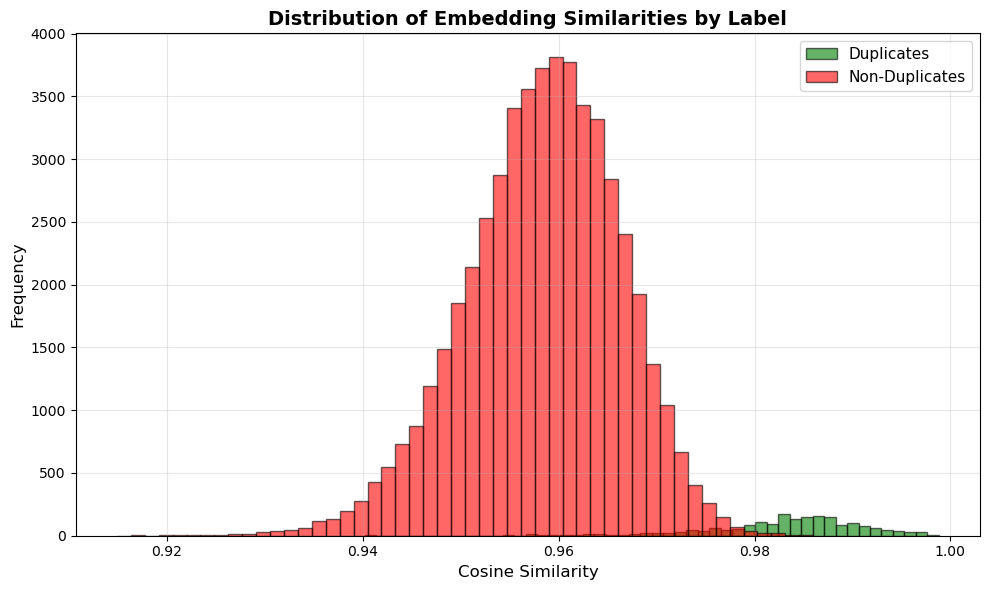

In [210]:
# Compute similarities if not already done
if 'similarity' not in train_last_name_pairs.columns:
    train_embed_indexed = train_embed.set_index('id')
    
    def get_sim(id1, id2):
        try:
            vec1 = train_embed_indexed.loc[id1].values
            vec2 = train_embed_indexed.loc[id2].values
            return np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
        except:
            return np.nan
    
    train_last_name_pairs['similarity'] = train_last_name_pairs.apply(
        lambda row: get_sim(row['id1'], row['id2']),
        axis=1
    )

# Plot histogram
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Separate by label
dup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 1]['similarity']
ndup_sims = train_last_name_pairs[train_last_name_pairs['label'] == 0]['similarity']

# Plot histograms
ax.hist(dup_sims.dropna(), bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
ax.hist(ndup_sims.dropna(), bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')

ax.set_xlabel('Cosine Similarity', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Embedding Similarities by Label', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [214]:
def evaluate_model(ids_data, pairs_data, vocab_size=38, embed_dim=32, num_filters=128, 
                   kernel_sizes=(3, 4, 5), dropout=0.3, output_dim=128, thresholds=None):
    """
    Evaluate embedding model with given parameters.
    
    Parameters:
    -----------
    ids_data : pd.DataFrame
        DataFrame with columns: id, first_name, middle_name, last_name, age, sex
    pairs_data : pd.DataFrame
        DataFrame with columns: id1, id2, label (1 for duplicate, 0 for non-duplicate)
    vocab_size : int
        Vocabulary size for character mapping
    embed_dim : int
        Character embedding dimension
    num_filters : int
        Number of CNN filters
    kernel_sizes : tuple
        Kernel sizes for CNN
    dropout : float
        Dropout rate
    output_dim : int
        Output embedding dimension
    thresholds : list
        Thresholds to evaluate (default: [0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99])
    
    Returns:
    --------
    dict with keys:
        - 'embeddings': Generated embeddings dataframe
        - 'similarities': Dataframe with pairs and their similarity scores
        - 'metrics_df': Metrics at each threshold
        - 'best_f1': Best F1 score
        - 'best_threshold': Threshold with best F1
    """
    if thresholds is None:
        thresholds = [0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99]
    
    print("=" * 60)
    print(f"Model Configuration:")
    print(f"  vocab_size={vocab_size}, embed_dim={embed_dim}")
    print(f"  num_filters={num_filters}, kernel_sizes={kernel_sizes}")
    print(f"  dropout={dropout}, output_dim={output_dim}")
    print("=" * 60)
    
    # Create model
    model_eval = src.model.CharCNNEncoder(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        num_filters=num_filters,
        kernel_sizes=kernel_sizes,
        dropout=dropout,
        output_dim=output_dim
    )
    
    # Generate embeddings
    print("\n1. Generating embeddings...")
    embeddings = src.model_utils.get_embeddings(ids_data, model_eval)
    embeddings_indexed = embeddings.set_index('id')
    print(f"   ✓ Generated embeddings shape: {embeddings.shape}")
    print(f"   ✓ NaN values: {embeddings.isnull().sum().sum()}")
    
    # Compute similarities
    print("\n2. Computing similarities...")
    similarities = []
    for idx, row in pairs_data.iterrows():
        id1, id2 = row['id1'], row['id2']
        try:
            vec1 = embeddings_indexed.loc[id1].values
            vec2 = embeddings_indexed.loc[id2].values
            sim = np.dot(vec1, vec2) / (np.linalg.norm(vec1) * np.linalg.norm(vec2))
            similarities.append(sim)
        except KeyError:
            similarities.append(np.nan)
    
    pairs_with_sim = pairs_data.copy()
    pairs_with_sim['similarity'] = similarities
    print(f"   ✓ Computed {len(pairs_with_sim)} pair similarities")
    print(f"   ✓ Missing values: {pairs_with_sim['similarity'].isnull().sum()}")
    
    # Separate by label
    dup_sims = pairs_with_sim[pairs_with_sim['label'] == 1]['similarity'].dropna()
    ndup_sims = pairs_with_sim[pairs_with_sim['label'] == 0]['similarity'].dropna()
    
    print(f"\n3. Similarity Statistics:")
    print(f"   Duplicates (n={len(dup_sims)}): mean={dup_sims.mean():.4f}, std={dup_sims.std():.4f}")
    print(f"   Non-dups (n={len(ndup_sims)}): mean={ndup_sims.mean():.4f}, std={ndup_sims.std():.4f}")
    
    # Evaluate thresholds
    print(f"\n4. Evaluating thresholds...")
    metrics_results = []
    for thresh in thresholds:
        predictions = (pairs_with_sim['similarity'] > thresh).astype(int)
        actuals = pairs_with_sim['label'].astype(int)
        
        tn, fp, fn, tp = confusion_matrix(actuals, predictions).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        
        metrics_results.append({
            'Threshold': thresh,
            'Precision': precision,
            'Recall': recall,
            'F1': f1,
            'Accuracy': accuracy,
            'TP': tp,
            'FP': fp,
            'FN': fn,
            'TN': tn
        })
    
    metrics_df = pd.DataFrame(metrics_results)
    best_f1_idx = metrics_df['F1'].idxmax()
    best_f1 = metrics_df.loc[best_f1_idx, 'F1']
    best_threshold = metrics_df.loc[best_f1_idx, 'Threshold']
    
    print(f"\n   Best F1: {best_f1:.4f} at threshold {best_threshold:.3f}")
    
    # Create visualizations
    print(f"\n5. Creating visualizations...")
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Histogram
    ax1.hist(dup_sims, bins=50, alpha=0.6, label='Duplicates', color='green', edgecolor='black')
    ax1.hist(ndup_sims, bins=50, alpha=0.6, label='Non-Duplicates', color='red', edgecolor='black')
    ax1.set_xlabel('Cosine Similarity', fontsize=11)
    ax1.set_ylabel('Frequency', fontsize=11)
    ax1.set_title('Distribution of Embedding Similarities', fontsize=12, fontweight='bold')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # Precision-Recall Curve
    precisions_pr, recalls_pr, _ = precision_recall_curve(
        pairs_with_sim['label'].astype(int),
        pairs_with_sim['similarity']
    )
    ax2.plot(recalls_pr, precisions_pr, linewidth=2, color='blue')
    ax2.scatter(metrics_df['Recall'], metrics_df['Precision'], c=metrics_df['Threshold'], 
                cmap='viridis', s=100, zorder=5)
    ax2.set_xlabel('Recall', fontsize=11)
    ax2.set_ylabel('Precision', fontsize=11)
    ax2.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # F1 vs Threshold
    ax3.plot(metrics_df['Threshold'], metrics_df['F1'], 'o-', linewidth=2, 
             markersize=8, label='F1', color='blue')
    ax3.plot(metrics_df['Threshold'], metrics_df['Precision'], 's-', linewidth=2, 
             markersize=6, label='Precision', color='orange')
    ax3.plot(metrics_df['Threshold'], metrics_df['Recall'], '^-', linewidth=2, 
             markersize=6, label='Recall', color='green')
    ax3.axvline(best_threshold, color='red', linestyle='--', alpha=0.7, label='Best F1')
    ax3.set_xlabel('Threshold', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('Metrics vs Similarity Threshold', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Confusion Matrix at best threshold
    best_preds = (pairs_with_sim['similarity'] > best_threshold).astype(int)
    best_cm = confusion_matrix(pairs_with_sim['label'].astype(int), best_preds)
    sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', ax=ax4, cbar=False,
                xticklabels=['Non-Dup', 'Dup'], yticklabels=['Non-Dup', 'Dup'])
    ax4.set_ylabel('Actual', fontsize=11)
    ax4.set_xlabel('Predicted', fontsize=11)
    ax4.set_title(f'Confusion Matrix (threshold={best_threshold:.3f}, F1={best_f1:.4f})', 
                  fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n" + "=" * 60)
    print("THRESHOLD EVALUATION RESULTS:")
    print("=" * 60)
    print(metrics_df.to_string(index=False))
    print("=" * 60)
    
    return {
        'embeddings': embeddings,
        'similarities': pairs_with_sim,
        'metrics_df': metrics_df,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'dup_sims': dup_sims,
        'ndup_sims': ndup_sims
    }

In [212]:
# Import required visualization library
import seaborn as sns

Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

1. Generating embeddings...
   ✓ Generated embeddings shape: (9750, 129)
   ✓ NaN values: 0

2. Computing similarities...
   ✓ Computed 53781 pair similarities
   ✓ Missing values: 0

3. Similarity Statistics:
   Duplicates (n=1930): mean=0.9794, std=0.0086
   Non-dups (n=51851): mean=0.9506, std=0.0089

4. Evaluating thresholds...

   Best F1: 0.8289 at threshold 0.975

5. Creating visualizations...


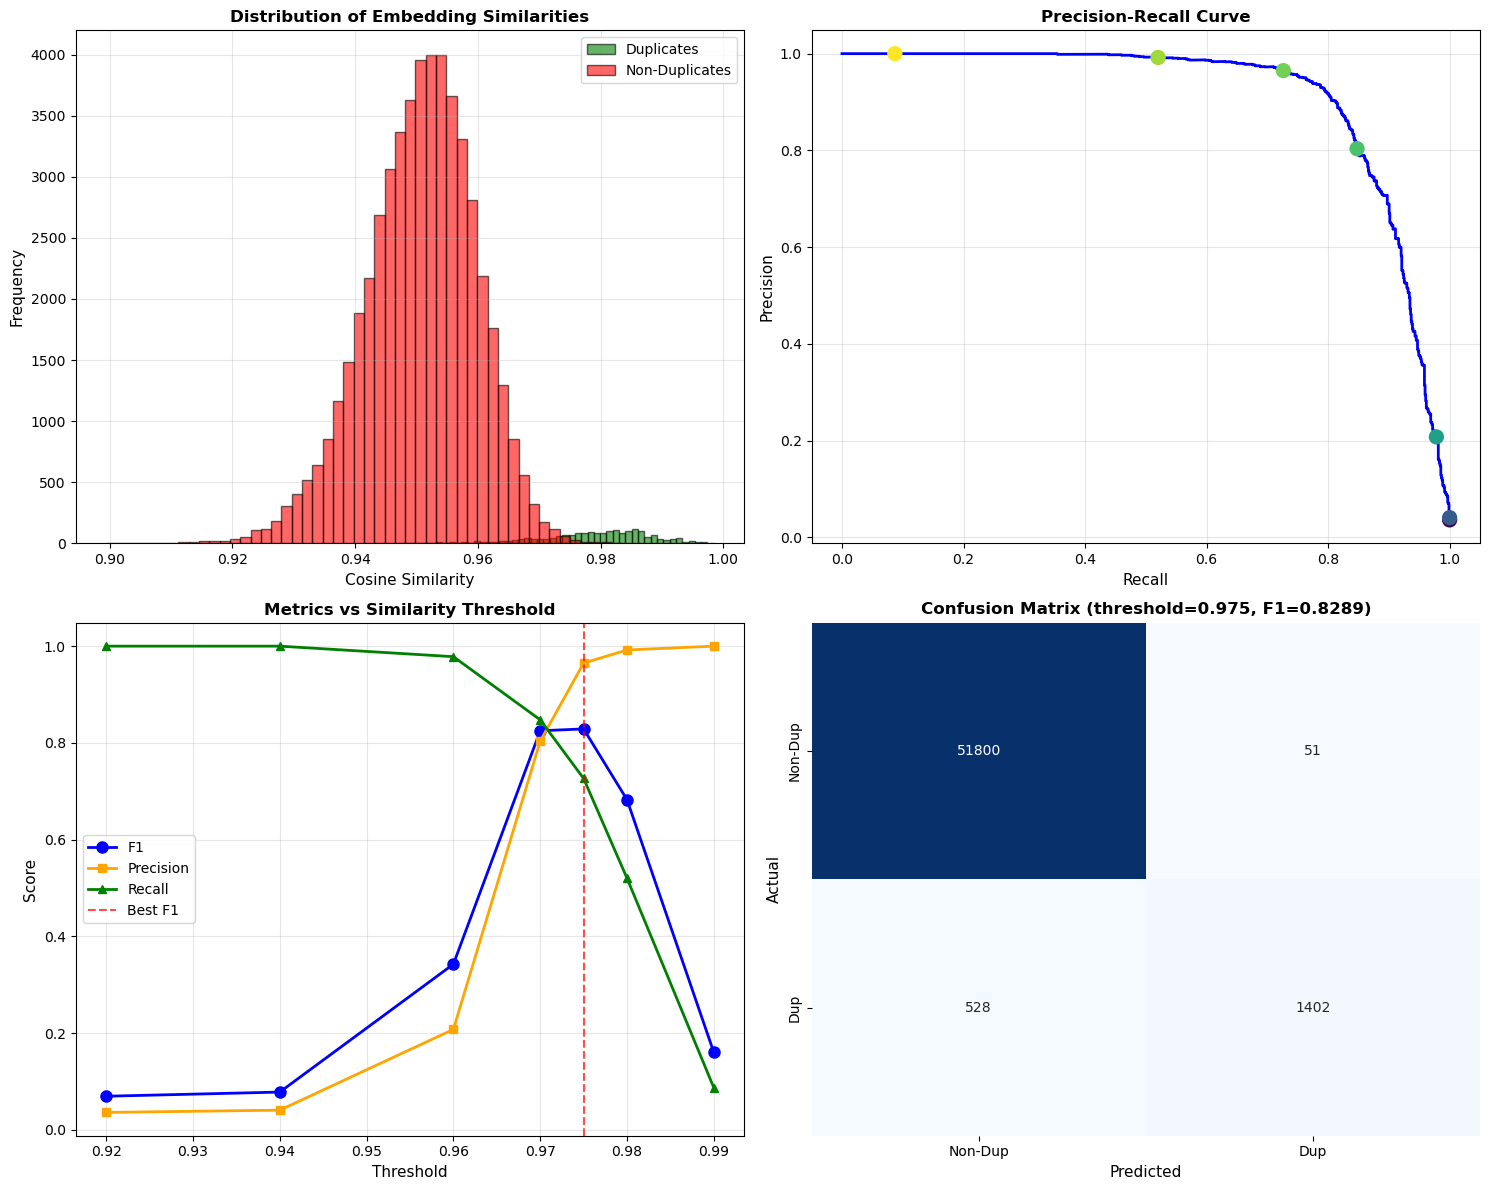


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035948 1.000000 0.069402  0.037616 1930 51758    0    93
     0.940   0.040580 1.000000 0.077996  0.151559 1930 45630    0  6221
     0.960   0.207564 0.978238 0.342463  0.865194 1888  7208   42 44643
     0.970   0.803536 0.847668 0.825013  0.987096 1636   400  294 51451
     0.975   0.964900 0.726425 0.828850  0.989234 1402    51  528 51800
     0.980   0.992095 0.520207 0.682529  0.982633 1004     8  926 51843
     0.990   1.000000 0.087047 0.160153  0.967238  168     0 1762 51851

✓ Results stored in 'results' dictionary
  Available keys: ['embeddings', 'similarities', 'metrics_df', 'best_f1', 'best_threshold', 'dup_sims', 'ndup_sims']


In [215]:
# Example usage: Evaluate the default model configuration
results = evaluate_model(
    ids_data=train_ids_data,
    pairs_data=train_last_name_pairs,
    vocab_size=38,
    embed_dim=32,
    num_filters=128,
    kernel_sizes=(3, 4, 5),
    dropout=0.3,
    output_dim=128
)

print("\n✓ Results stored in 'results' dictionary")
print("  Available keys:", list(results.keys()))

In [216]:
# Example: Compare different model configurations
configurations = [
    {
        'name': 'Small (embed=16, filters=64)',
        'vocab_size': 38,
        'embed_dim': 16,
        'num_filters': 64,
        'kernel_sizes': (3, 4, 5),
        'dropout': 0.3,
        'output_dim': 64
    },
    {
        'name': 'Medium (embed=32, filters=128)',
        'vocab_size': 38,
        'embed_dim': 32,
        'num_filters': 128,
        'kernel_sizes': (3, 4, 5),
        'dropout': 0.3,
        'output_dim': 128
    },
    {
        'name': 'Large (embed=64, filters=256)',
        'vocab_size': 38,
        'embed_dim': 64,
        'num_filters': 256,
        'kernel_sizes': (3, 4, 5),
        'dropout': 0.3,
        'output_dim': 256
    }
]

# You can evaluate any configuration by calling:
# results = evaluate_model(
#     ids_data=train_ids_data,
#     pairs_data=train_last_name_pairs,
#     vocab_size=38,
#     embed_dim=32,  # Change this
#     num_filters=128,  # Change this
#     kernel_sizes=(3, 4, 5),
#     dropout=0.3,
#     output_dim=128,  # Change this
#     thresholds=[0.92, 0.94, 0.96, 0.97, 0.975, 0.98, 0.99]
# )

print("Available configurations to test:")
for i, config in enumerate(configurations, 1):
    print(f"  {i}. {config['name']}")
print("\nTo test a configuration, modify and run the commented code above.")

Available configurations to test:
  1. Small (embed=16, filters=64)
  2. Medium (embed=32, filters=128)
  3. Large (embed=64, filters=256)

To test a configuration, modify and run the commented code above.


Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

   Best F1: 0.5147 at threshold 0.975


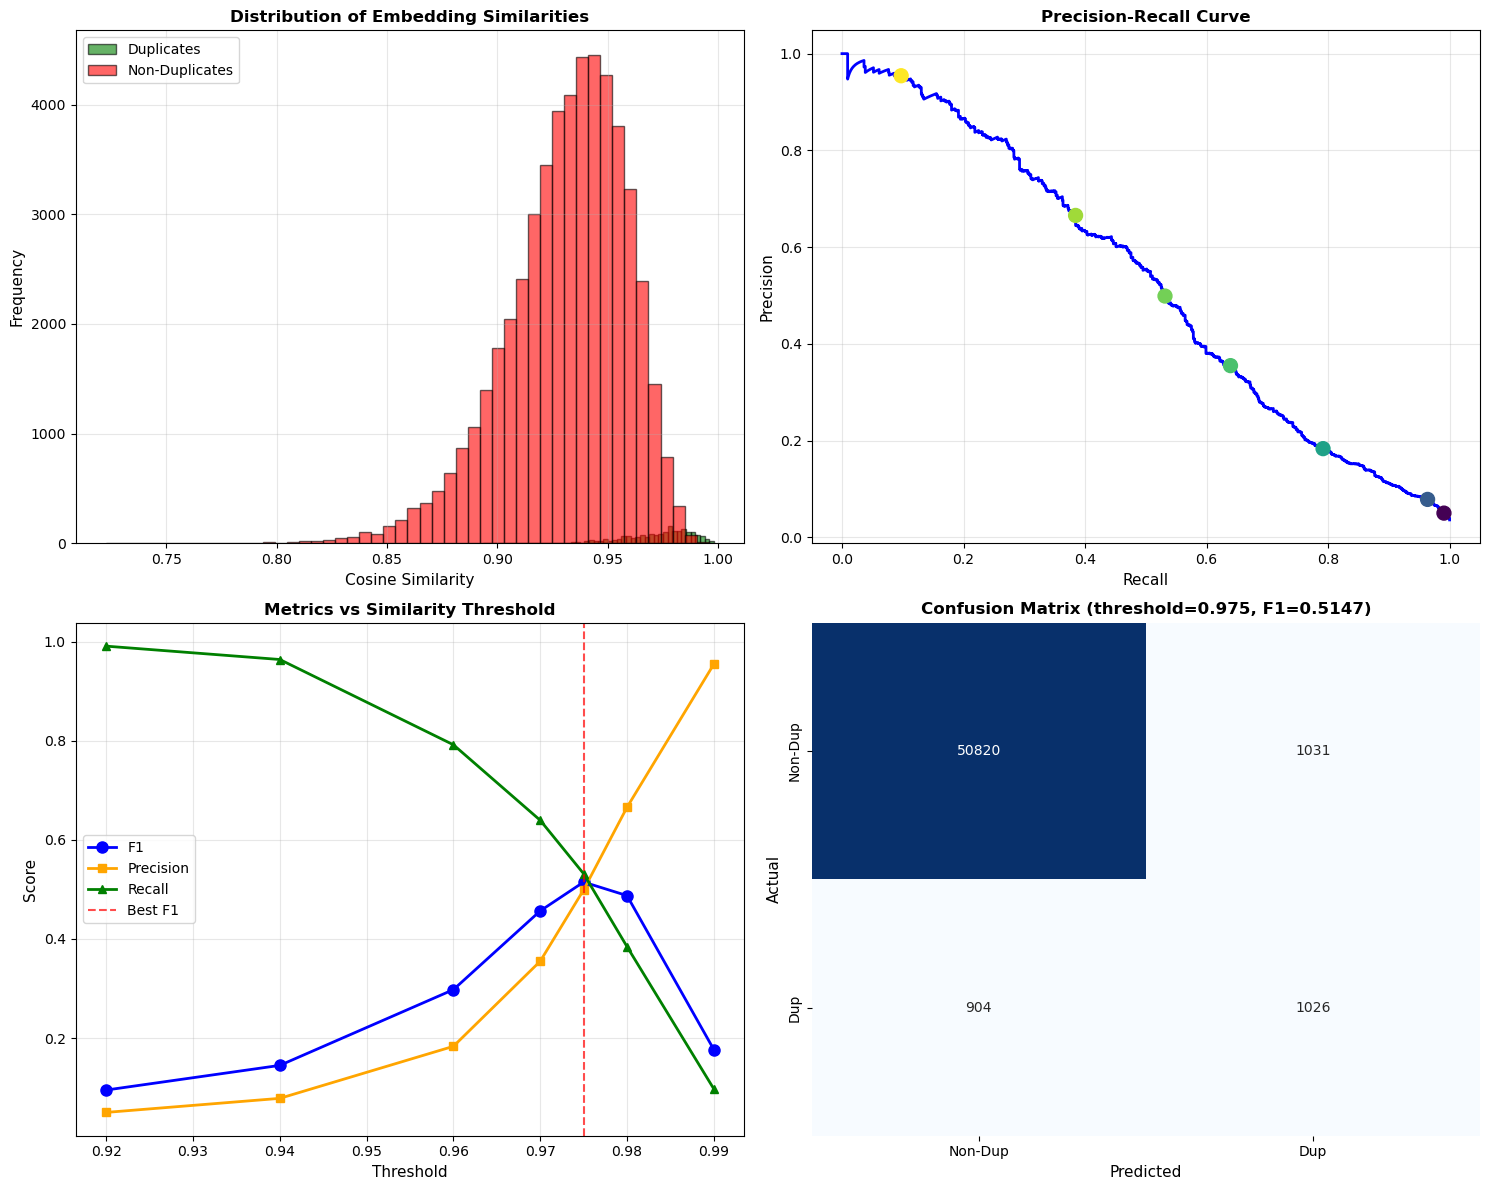


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.049920 0.990674 0.095051  0.323051 1912 36389   18 15462
     0.940   0.078273 0.963731 0.144787  0.591436 1860 21903   70 29948
     0.960   0.183235 0.791710 0.297595  0.865882 1528  6811  402 45040
     0.970   0.354904 0.639378 0.456445  0.945352 1234  2243  696 49608
     0.975   0.498785 0.531606 0.514673  0.964021 1026  1031  904 50820
     0.980   0.665471 0.384456 0.487356  0.970975  742   373 1188 51478
     0.990   0.954315 0.097409 0.176775  0.967442  188     9 1742 51842
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.6445 at threshold 0.990


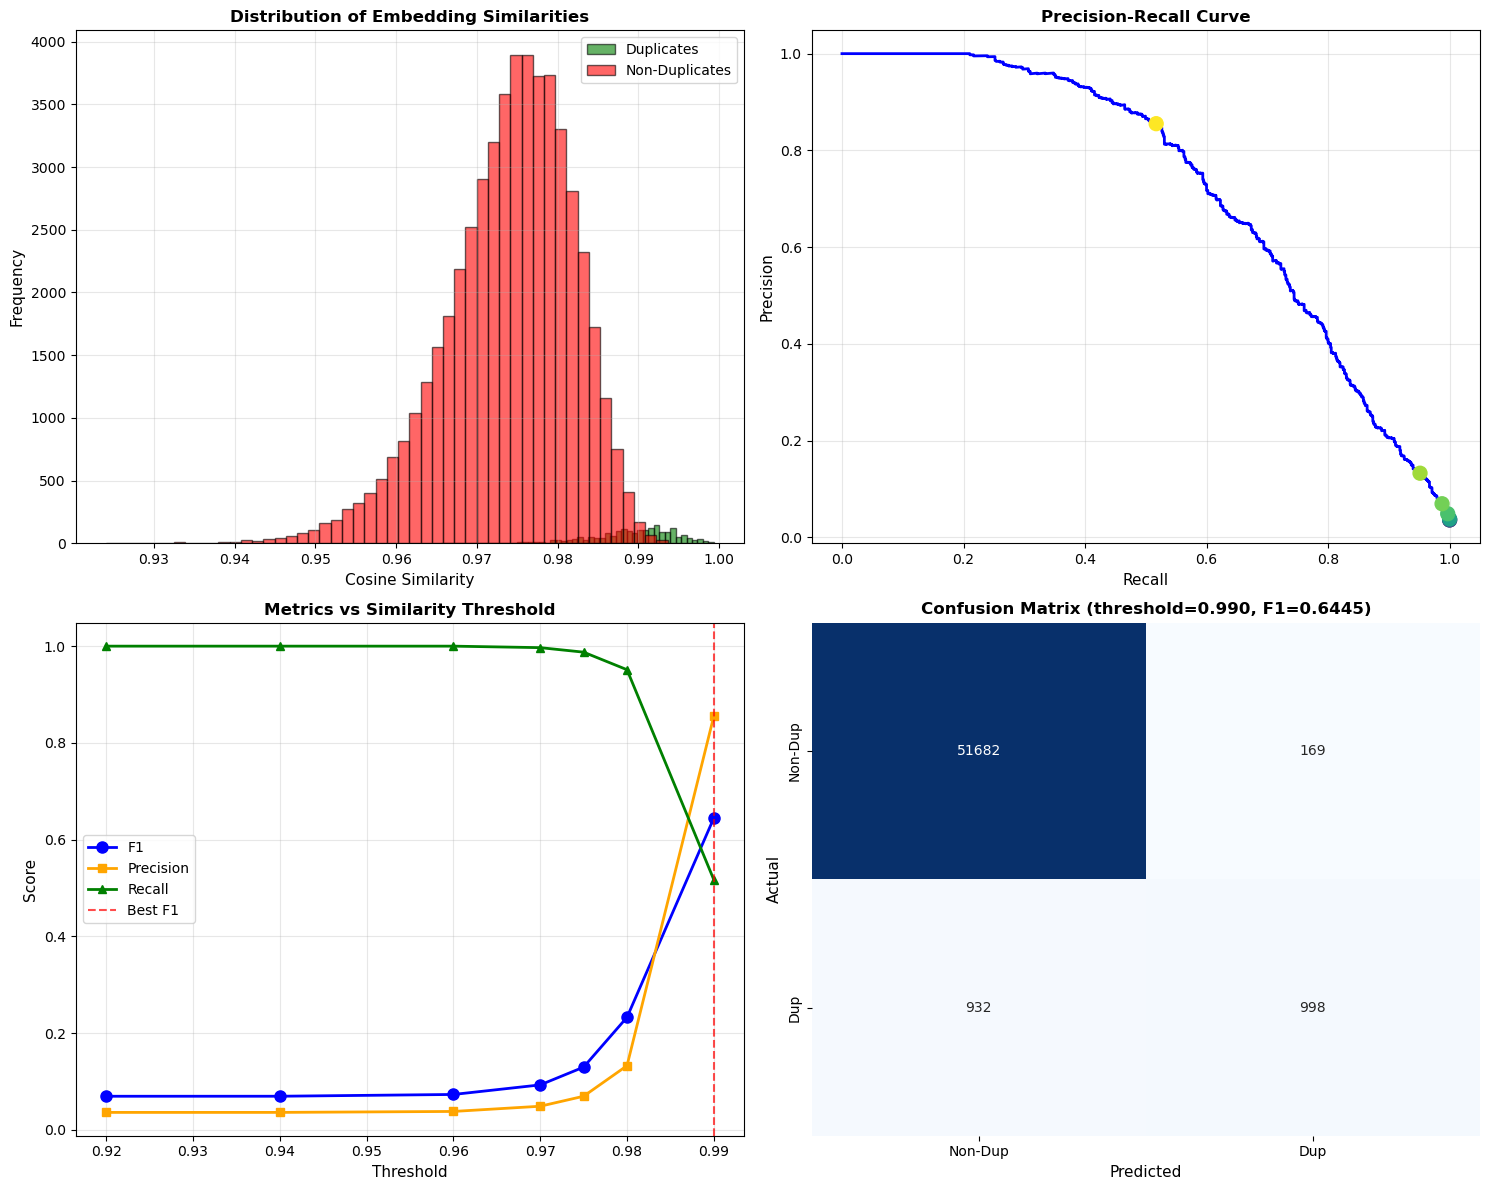


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP  FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851   0     0
     0.940   0.035910 1.000000 0.069331  0.036556 1930 51815   0    36
     0.960   0.037875 1.000000 0.072986  0.088396 1930 49027   0  2824
     0.970   0.048645 0.996891 0.092763  0.300236 1924 37628   6 14223
     0.975   0.069294 0.987565 0.129501  0.523549 1906 25600  24 26251
     0.980   0.132458 0.951295 0.232538  0.774660 1836 12025  94 39826
     0.990   0.855184 0.517098 0.644495  0.979528  998   169 932 51682
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.5052 at threshold 0.990


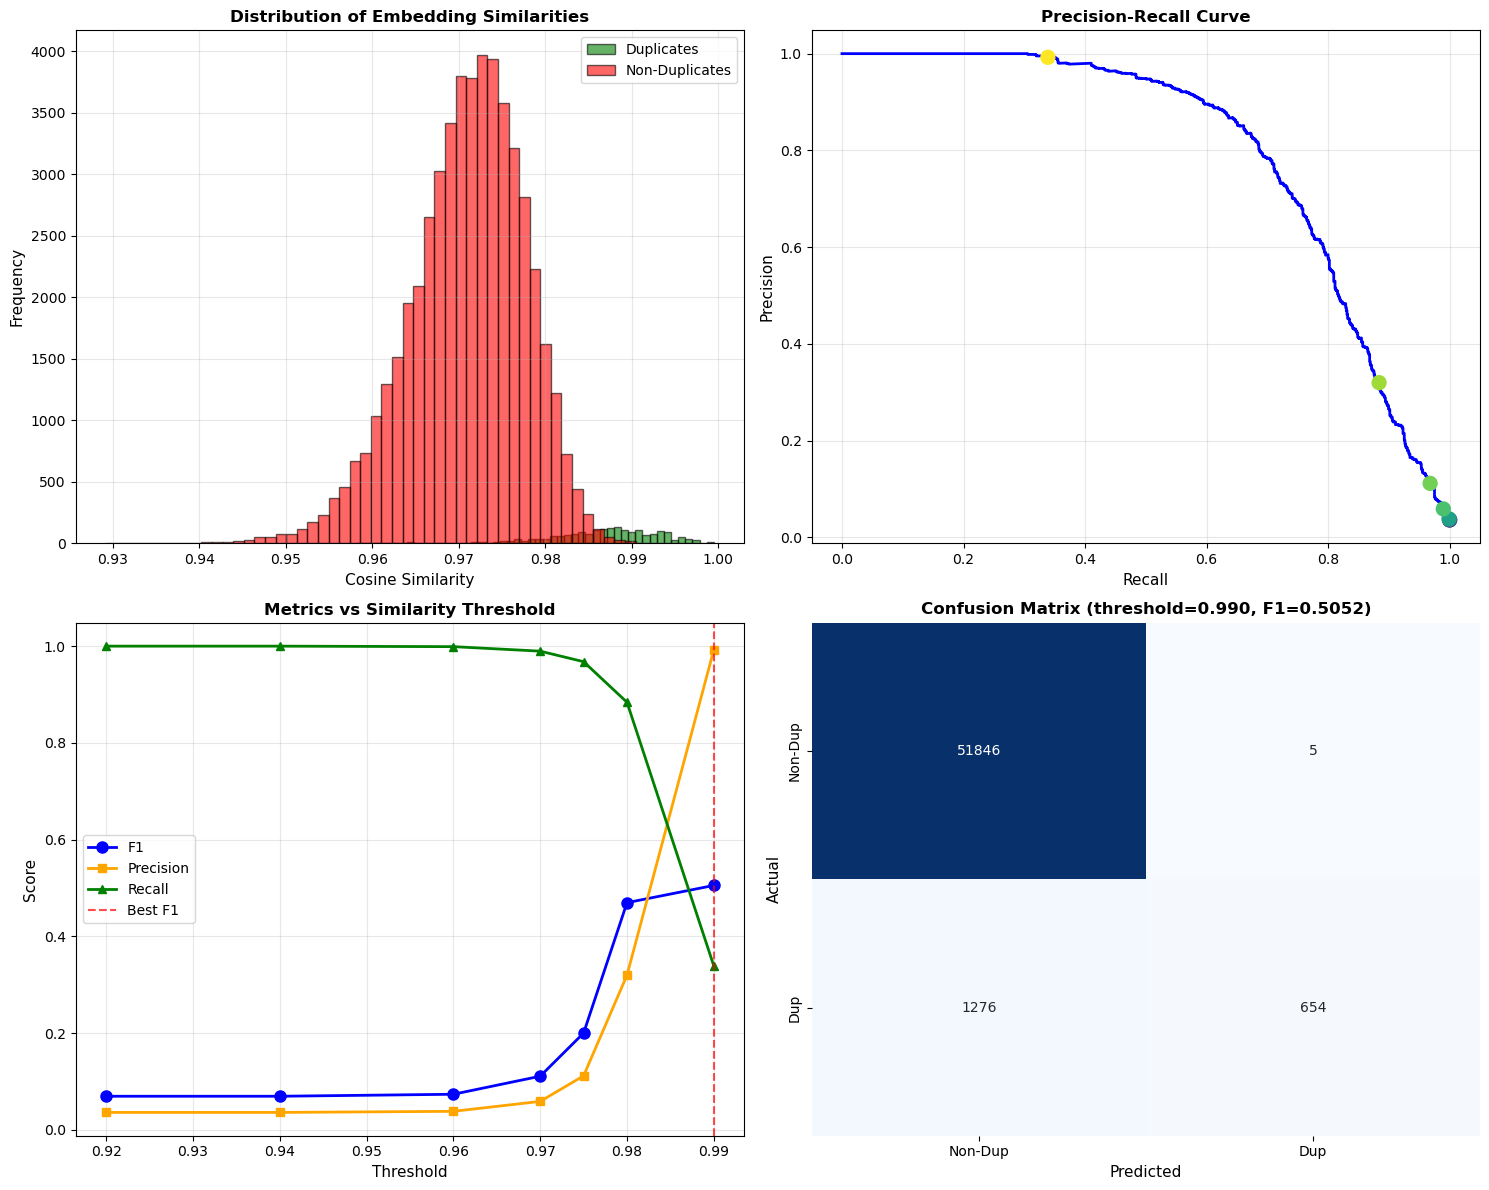


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035890 1.000000 0.069294  0.035998 1930 51845    0     6
     0.960   0.038110 0.998964 0.073420  0.095145 1928 48662    2  3189
     0.970   0.058643 0.989637 0.110725  0.429538 1910 30660   20 21191
     0.975   0.111469 0.967876 0.199914  0.721984 1868 14890   62 36961
     0.980   0.319715 0.883938 0.469584  0.928339 1706  3630  224 48221
     0.990   0.992413 0.338860 0.505214  0.976181  654     5 1276 51846
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8430 at threshold 0.980


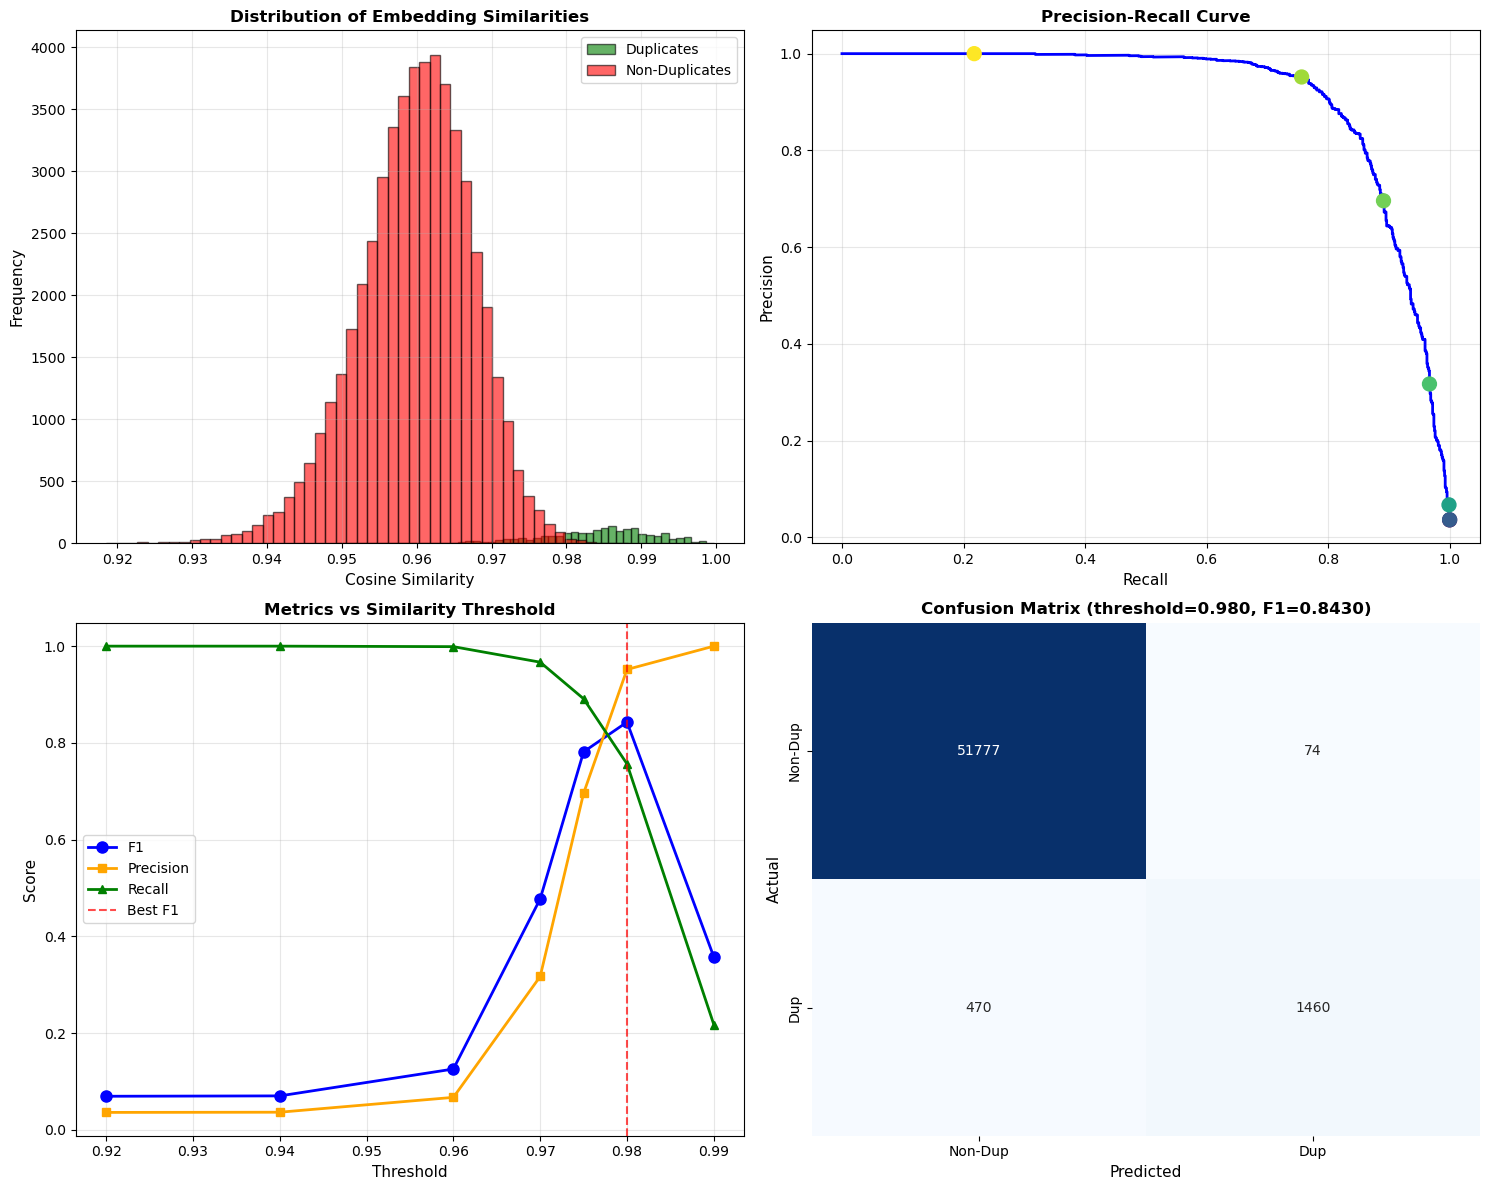


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035887 1.000000 0.069287  0.035905 1930 51850    0     1
     0.940   0.036292 1.000000 0.070042  0.047061 1930 51250    0   601
     0.960   0.067014 0.998964 0.125603  0.500865 1928 26842    2 25009
     0.970   0.316970 0.966839 0.477421  0.924044 1866  4021   64 47830
     0.975   0.695793 0.891192 0.781463  0.982113 1720   752  210 51099
     0.980   0.951760 0.756477 0.842956  0.989885 1460    74  470 51777
     0.990   1.000000 0.217617 0.357447  0.971923  420     0 1510 51851
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

   Best F1: 0.4873 at threshold 0.980


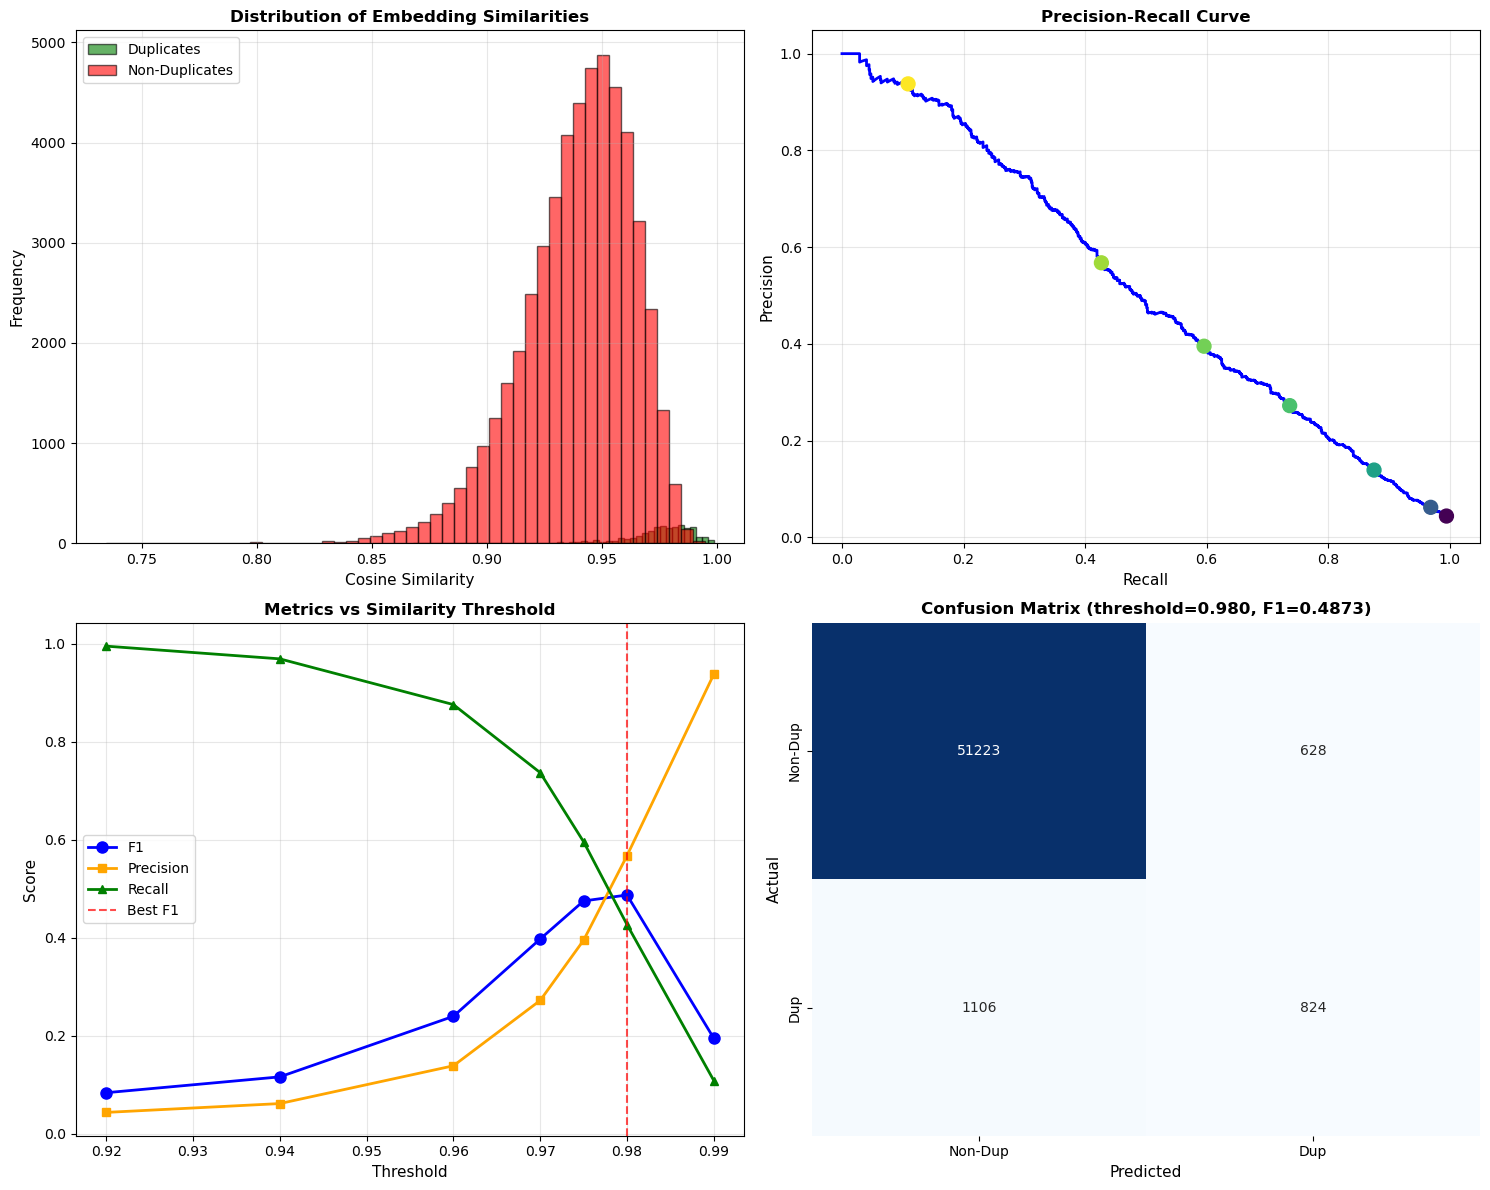


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.043876 0.994819 0.084045  0.221844 1920 41840   10 10011
     0.940   0.061892 0.968912 0.116351  0.471858 1870 28344   60 23507
     0.960   0.138969 0.875648 0.239869  0.800840 1690 10471  240 41380
     0.970   0.272205 0.736788 0.397540  0.919860 1422  3802  508 48049
     0.975   0.395053 0.595855 0.475108  0.952753 1150  1761  780 50090
     0.980   0.567493 0.426943 0.487286  0.967758  824   628 1106 51223
     0.990   0.937500 0.108808 0.194986  0.967758  210    14 1720 51837
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.7186 at threshold 0.980


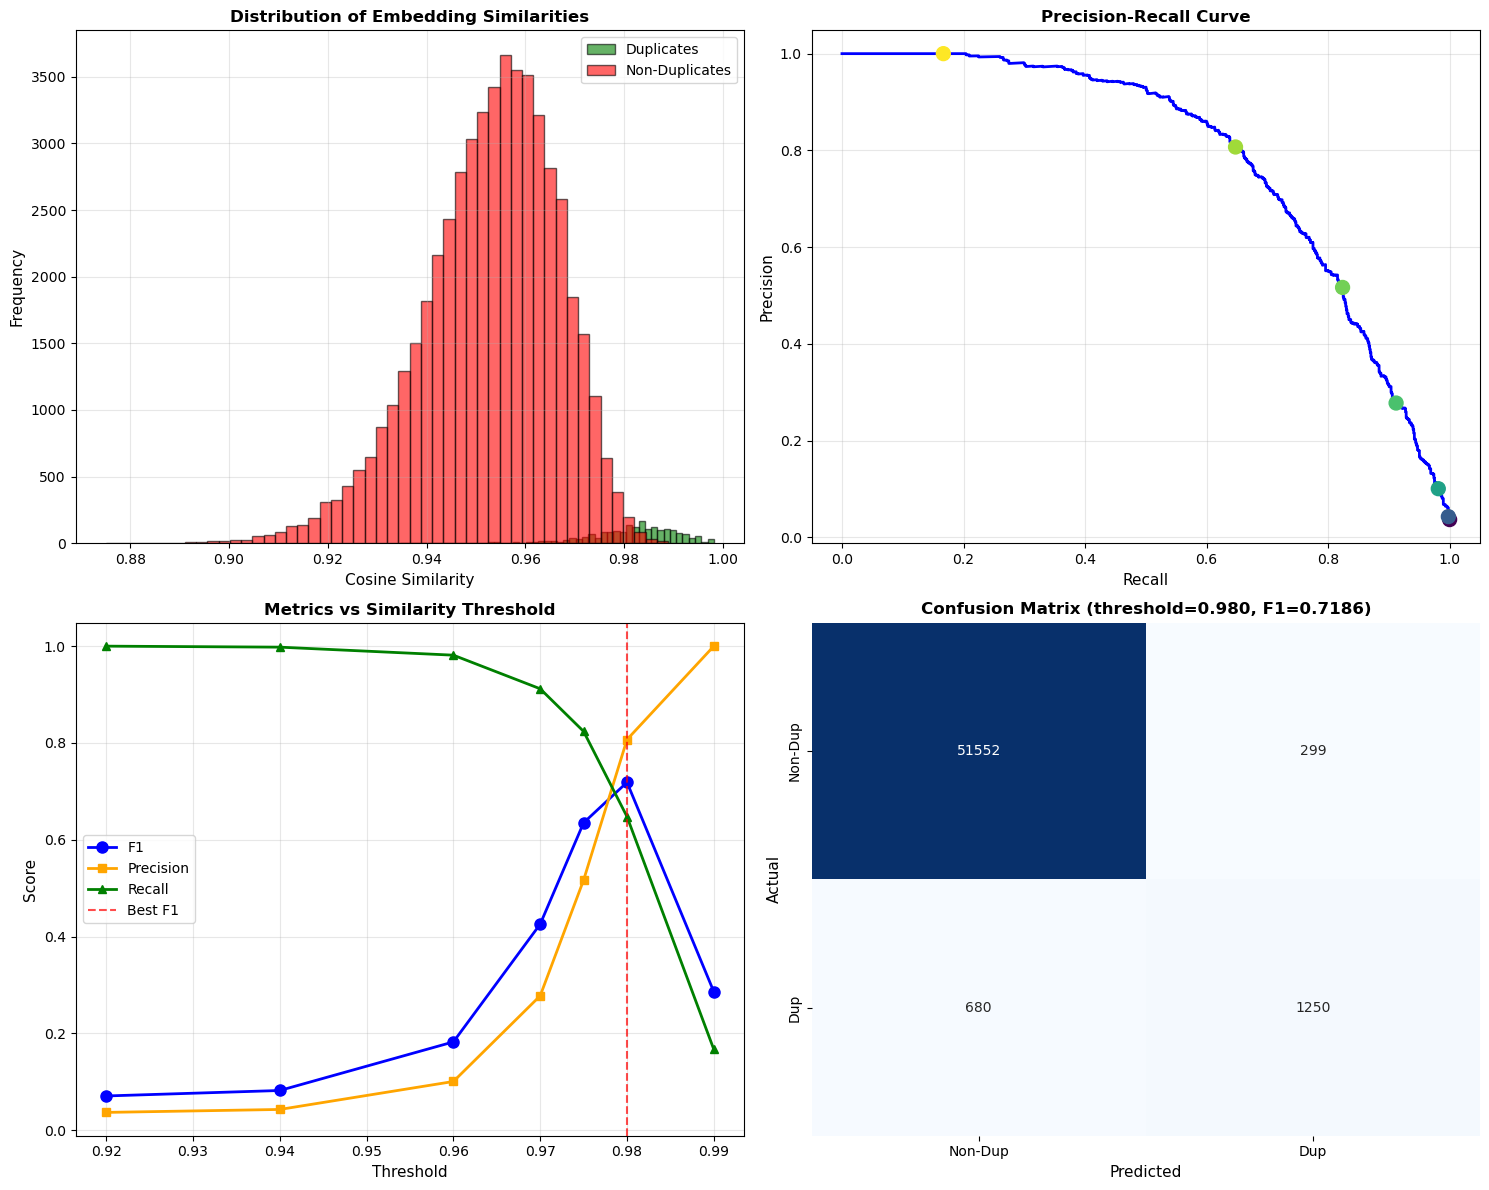


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.036561 1.000000 0.070544  0.054350 1930 50858    0   993
     0.940   0.042671 0.997927 0.081843  0.196482 1926 43210    4  8641
     0.960   0.100451 0.981347 0.182247  0.683959 1894 16961   36 34890
     0.970   0.277559 0.911917 0.425583  0.911660 1760  4581  170 47270
     0.975   0.516569 0.823834 0.634984  0.966010 1590  1488  340 50363
     0.980   0.806972 0.647668 0.718597  0.981797 1250   299  680 51552
     0.990   1.000000 0.166839 0.285968  0.970101  322     0 1608 51851
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.7155 at threshold 0.980


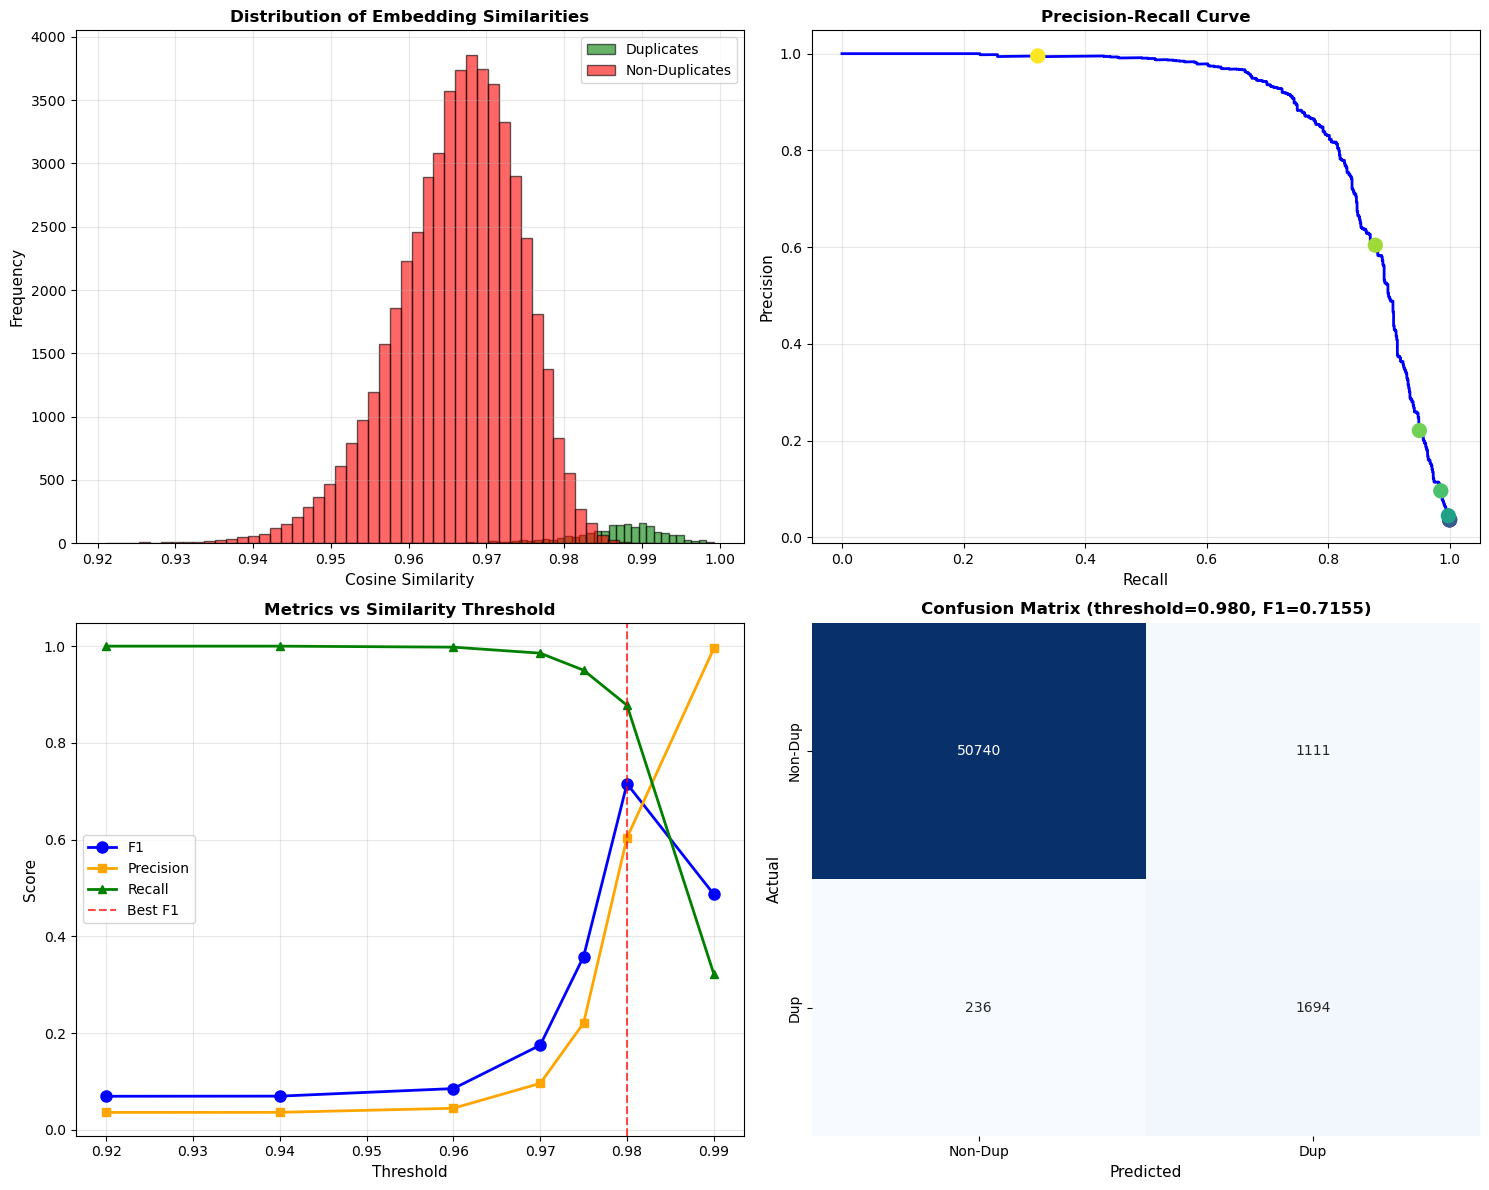


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.036019 1.000000 0.069533  0.039568 1930 51653    0   198
     0.960   0.044482 0.997927 0.085168  0.230658 1926 41372    4 10479
     0.970   0.095930 0.985492 0.174840  0.666183 1902 17925   28 33926
     0.975   0.220645 0.950259 0.358133  0.877764 1834  6478   96 45373
     0.980   0.603922 0.877720 0.715523  0.974954 1694  1111  236 50740
     0.990   0.995200 0.322280 0.486888  0.975623  622     3 1308 51848
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8475 at threshold 0.975


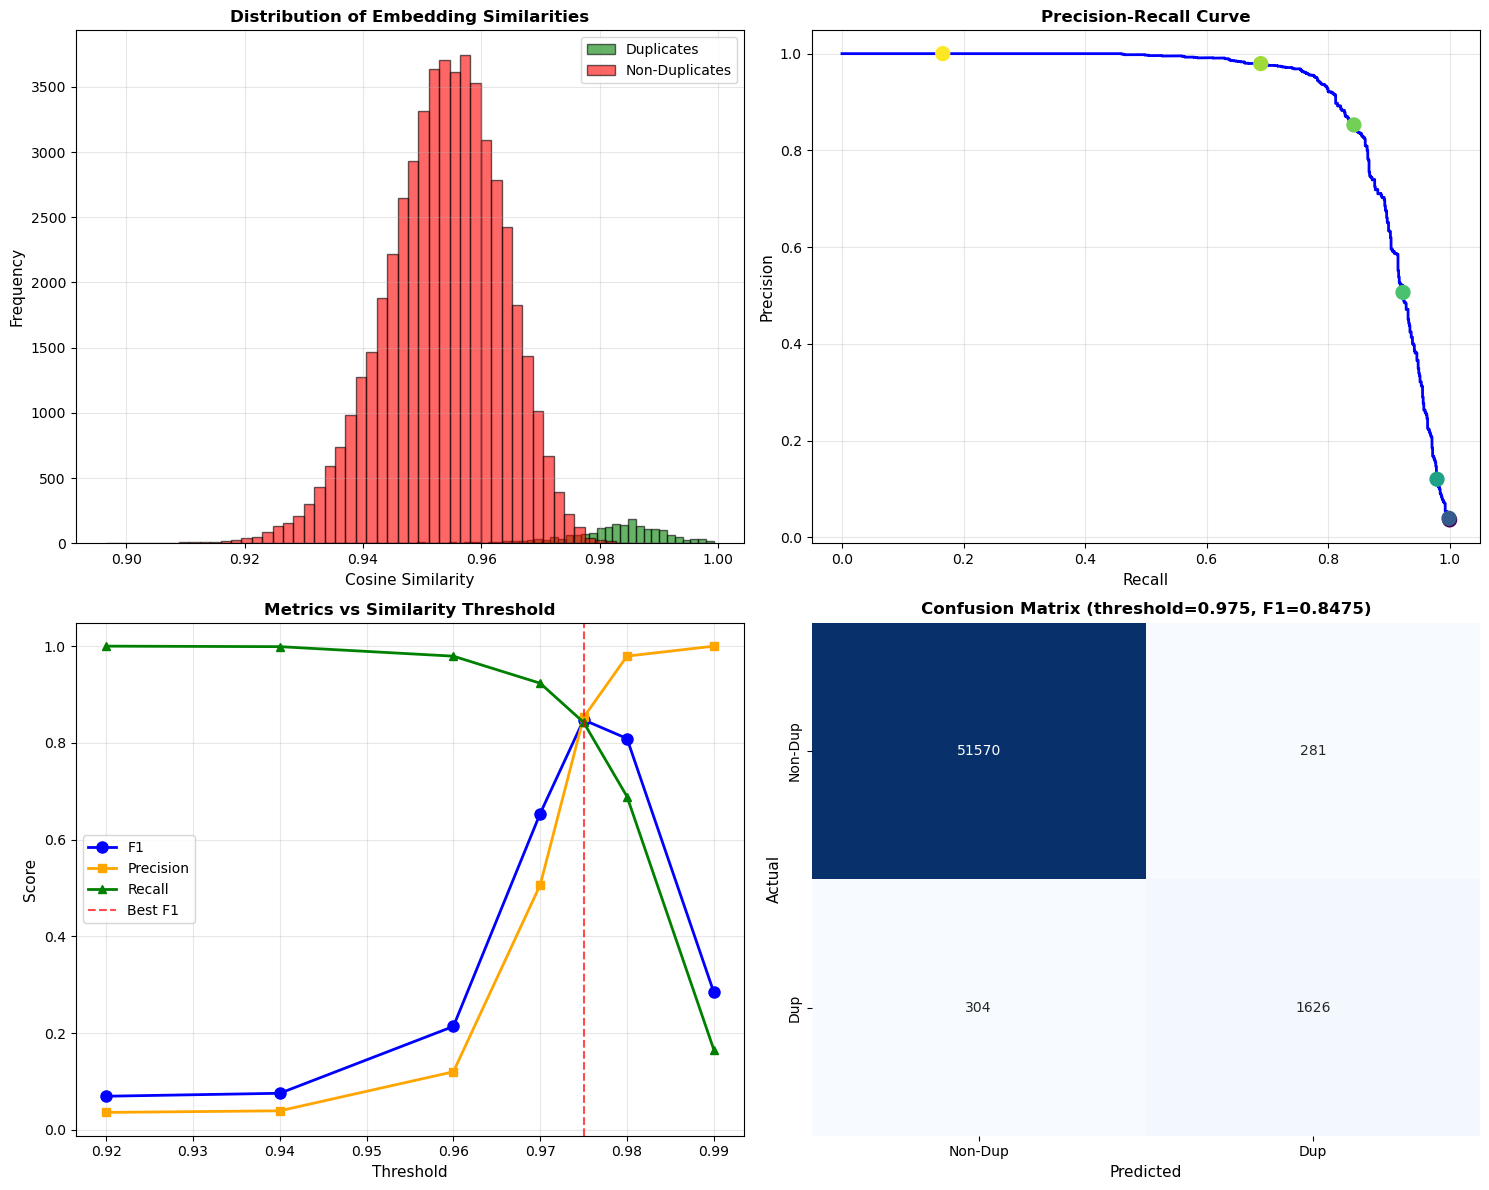


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035952 1.000000 0.069409  0.037727 1930 51752    0    99
     0.940   0.039235 0.998964 0.075504  0.122106 1928 47212    2  4639
     0.960   0.119954 0.979275 0.213728  0.741433 1890 13866   40 37985
     0.970   0.506250 0.923316 0.653945  0.964932 1782  1738  148 50113
     0.975   0.852648 0.842487 0.847537  0.989123 1626   281  304 51570
     0.980   0.979381 0.689119 0.809002  0.988323 1330    28  600 51823
     0.990   1.000000 0.165803 0.284444  0.970064  320     0 1610 51851
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

   Best F1: 0.5335 at threshold 0.975


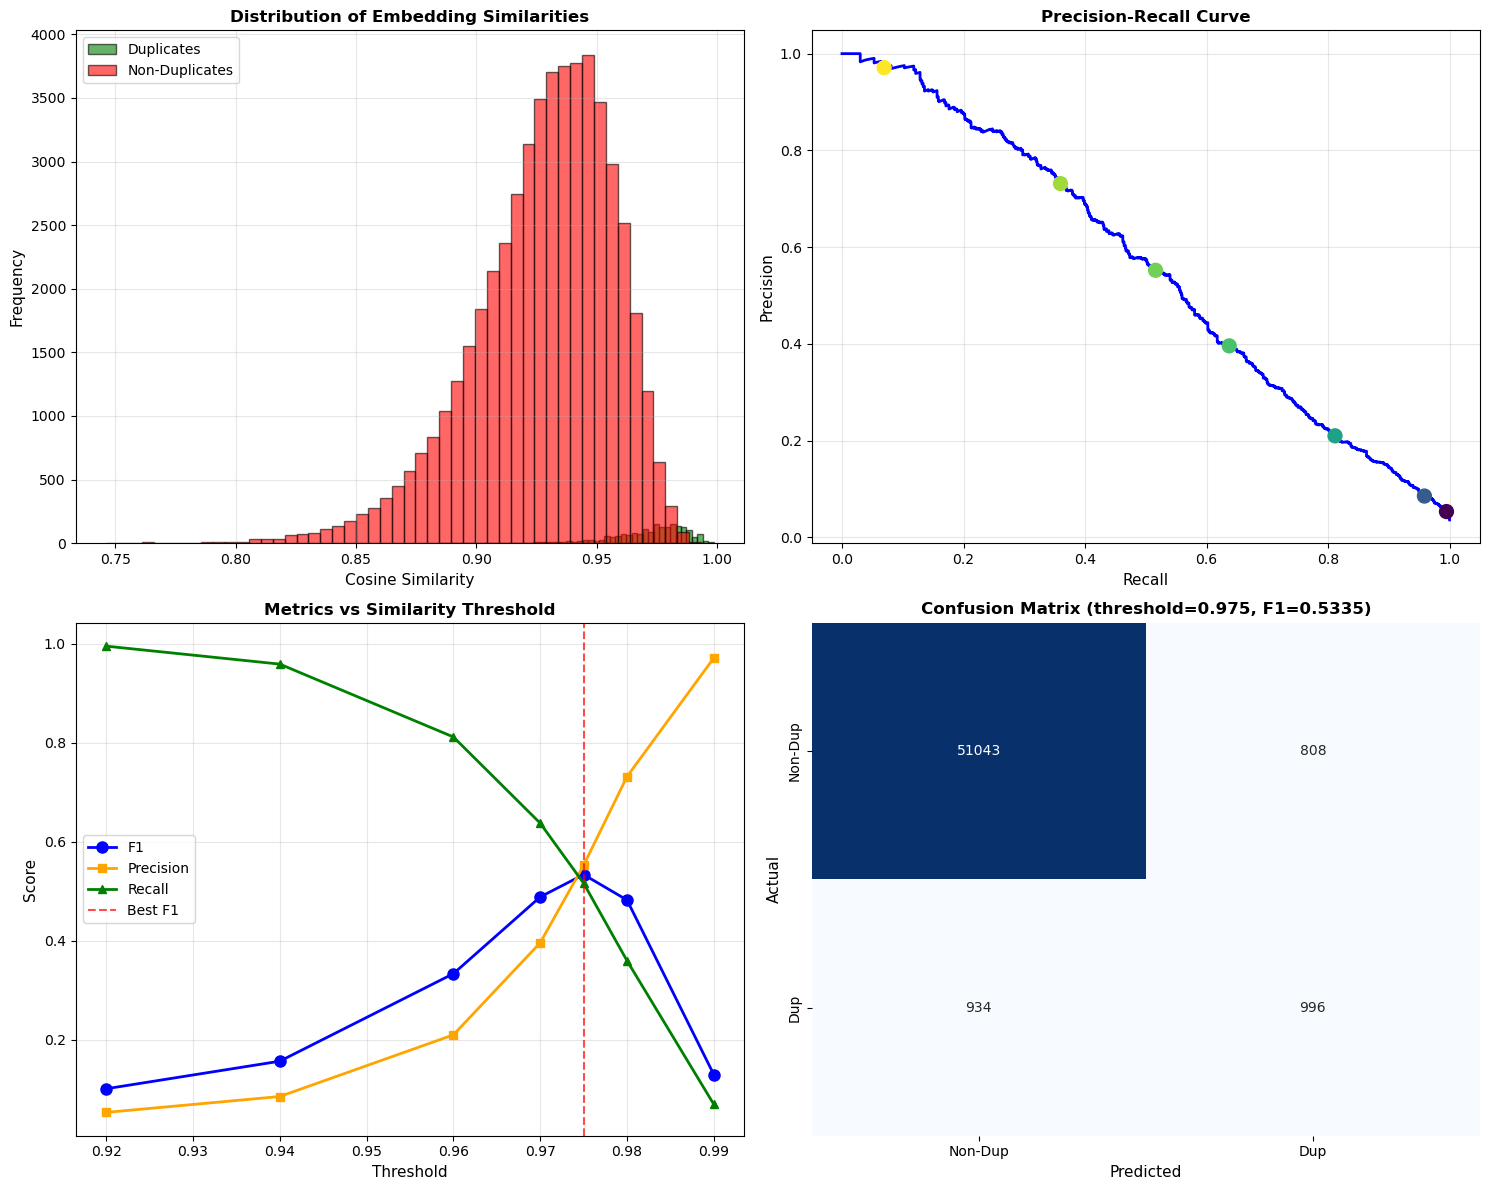


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.053130 0.994819 0.100872  0.363567 1920 34218   10 17633
     0.940   0.085230 0.958549 0.156541  0.629311 1850 19856   80 31995
     0.960   0.209751 0.811399 0.333333  0.883528 1566  5900  364 45951
     0.970   0.395753 0.637306 0.488289  0.952065 1230  1878  700 49973
     0.975   0.552106 0.516062 0.533476  0.967609  996   808  934 51043
     0.980   0.731296 0.359585 0.482112  0.972276  694   255 1236 51596
     0.990   0.971014 0.069430 0.129594  0.966531  134     4 1796 51847
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.5498 at threshold 0.990


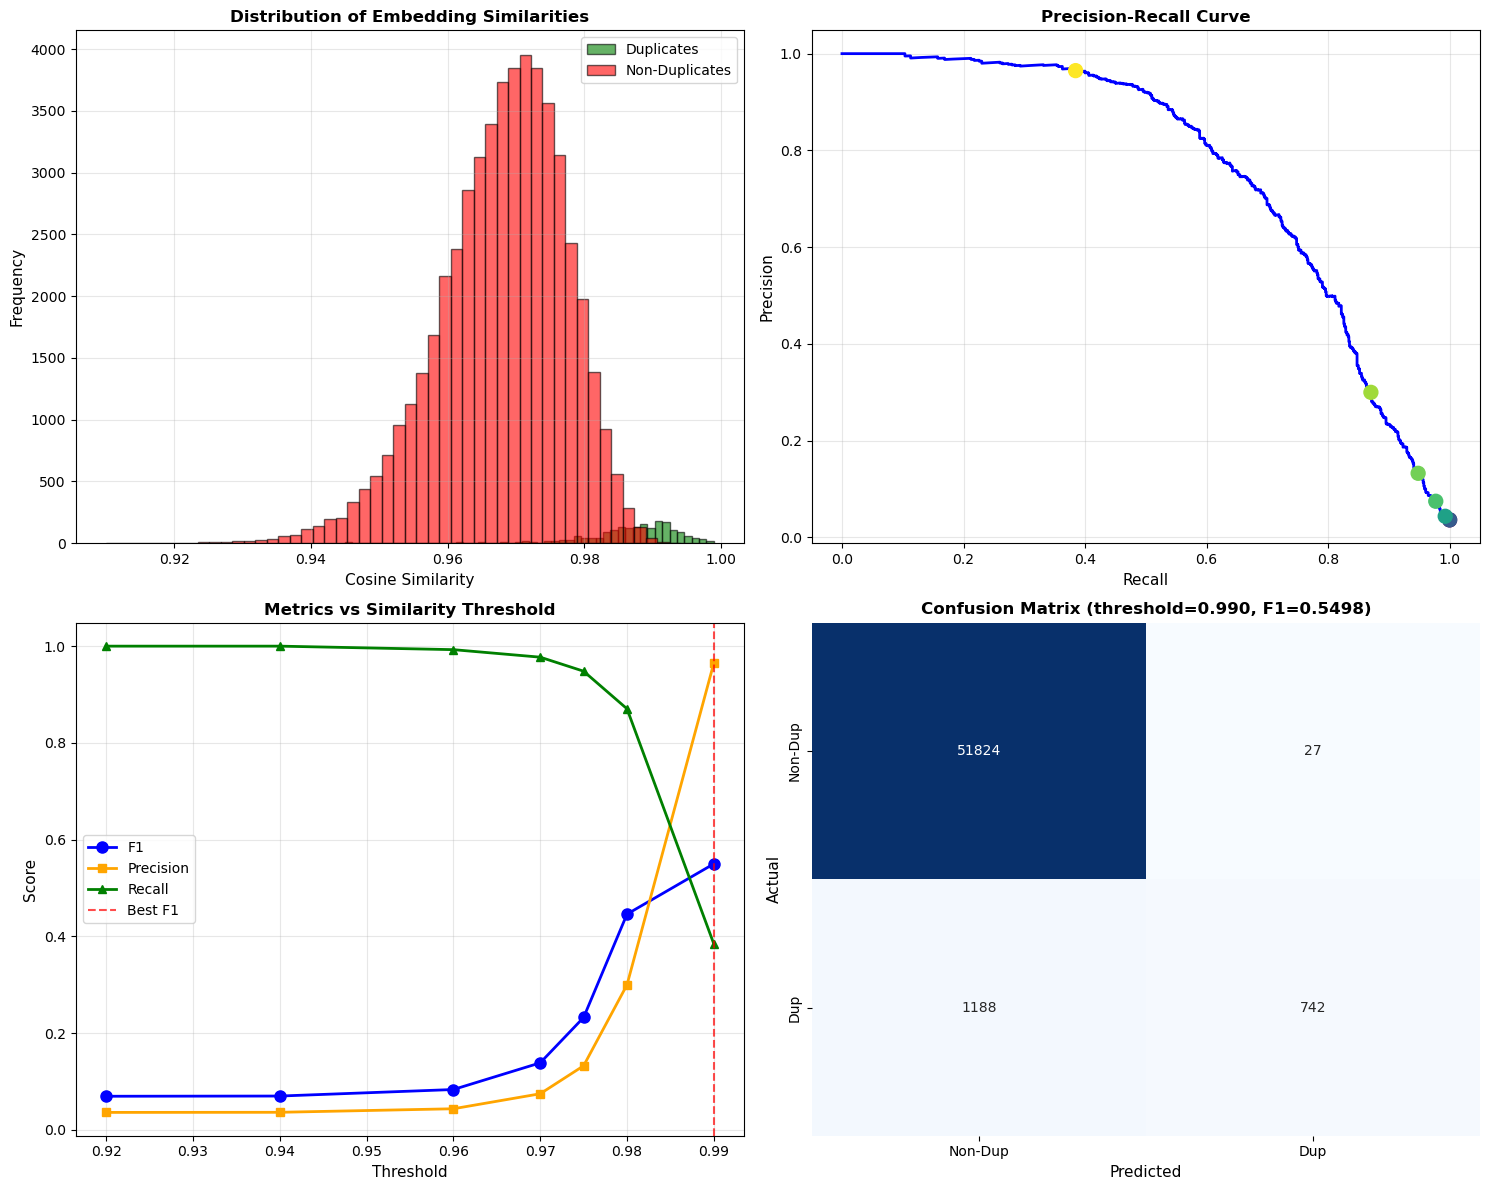


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035888 1.000000 0.069290  0.035942 1930 51848    0     3
     0.940   0.036120 1.000000 0.069722  0.042357 1930 51503    0   348
     0.960   0.043424 0.992746 0.083208  0.214946 1916 42207   14  9644
     0.970   0.074440 0.977202 0.138341  0.563154 1886 23450   44 28401
     0.975   0.132273 0.948187 0.232160  0.774921 1830 12005  100 39846
     0.980   0.299679 0.870466 0.445860  0.922352 1680  3926  250 47925
     0.990   0.964889 0.384456 0.549833  0.977408  742    27 1188 51824
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.8219 at threshold 0.975


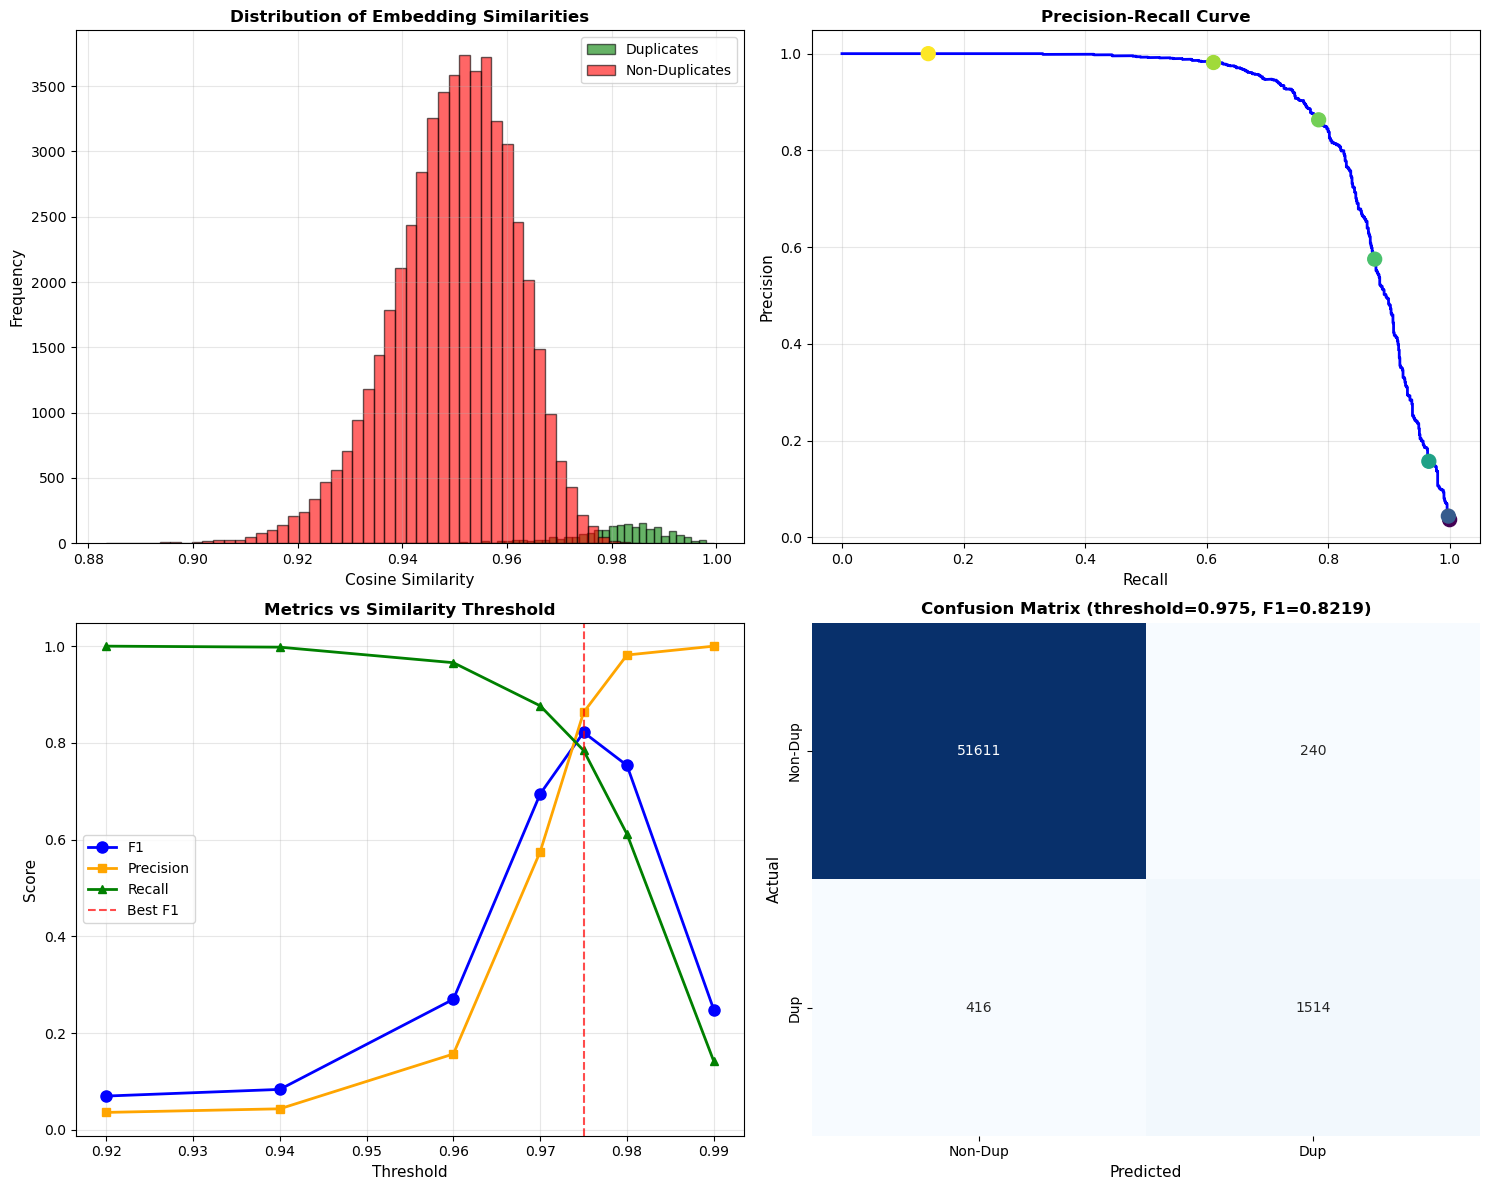


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.036344 1.000000 0.070140  0.048493 1930 51173    0   678
     0.940   0.043786 0.997927 0.083890  0.217846 1926 42061    4  9790
     0.960   0.157074 0.965803 0.270204  0.812778 1864 10003   66 41848
     0.970   0.575119 0.876684 0.694581  0.972332 1692  1250  238 50601
     0.975   0.863170 0.784456 0.821933  0.987802 1514   240  416 51611
     0.980   0.981697 0.611399 0.753512  0.985645 1180    22  750 51829
     0.990   1.000000 0.141969 0.248639  0.969208  274     0 1656 51851
Model Configuration:
  vocab_size=38, embed_dim=32
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.7895 at threshold 0.980


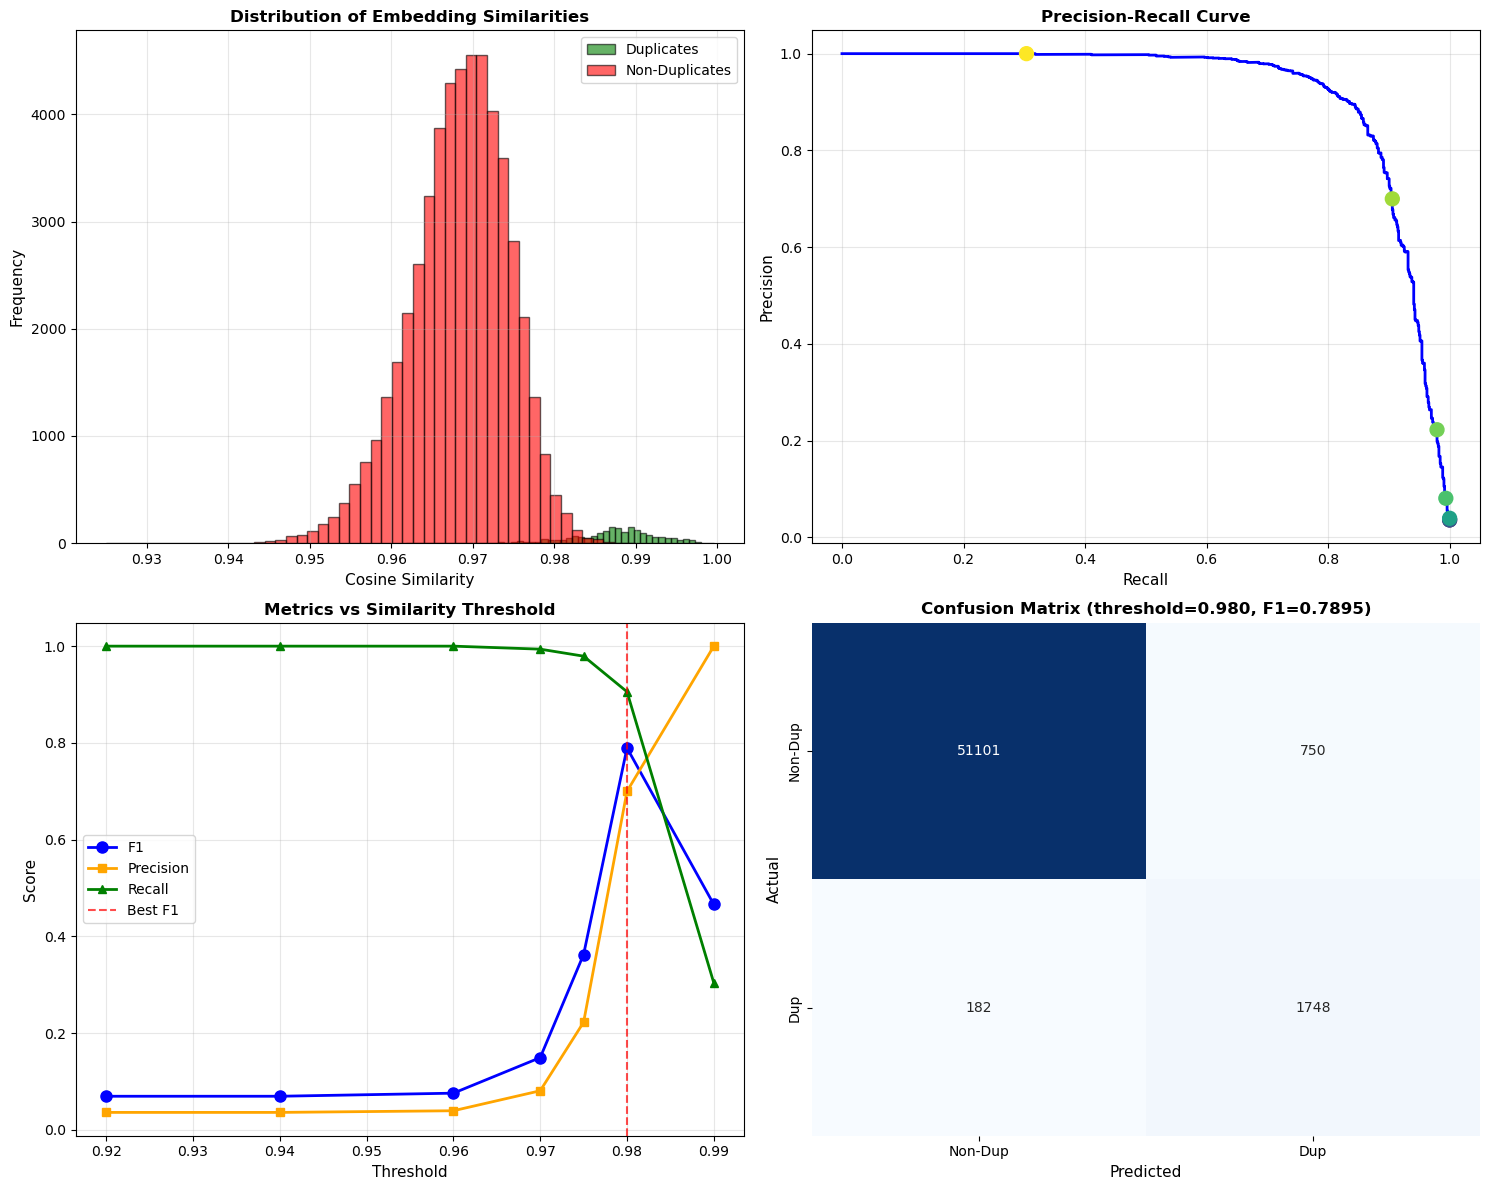


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035894 1.000000 0.069300  0.036091 1930 51840    0    11
     0.960   0.039316 1.000000 0.075658  0.123129 1930 47159    0  4692
     0.970   0.080629 0.993782 0.149156  0.593128 1918 21870   12 29981
     0.975   0.222327 0.979275 0.362381  0.876332 1890  6611   40 45240
     0.980   0.699760 0.905699 0.789521  0.982670 1748   750  182 51101
     0.990   1.000000 0.303627 0.465819  0.975010  586     0 1344 51851
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

   Best F1: 0.5204 at threshold 0.960


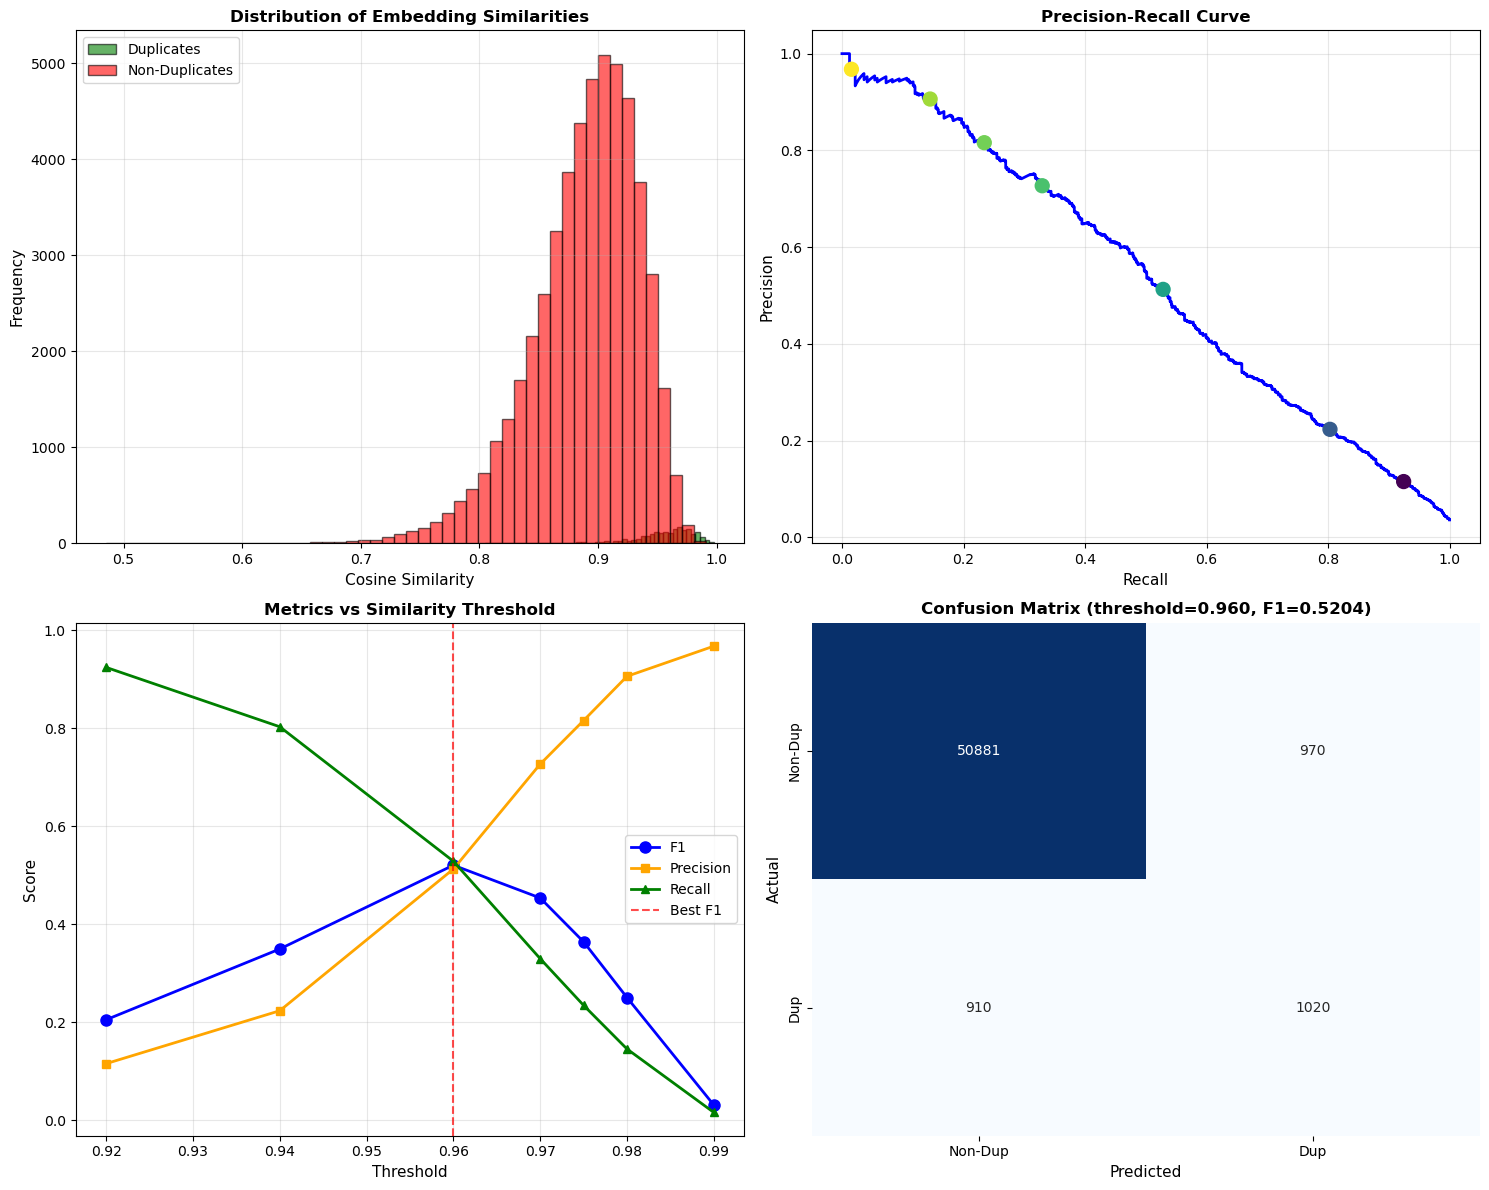


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.115171 0.924352 0.204822  0.742437 1784 13706  146 38145
     0.940   0.223182 0.803109 0.349296  0.892620 1550  5395  380 46456
     0.960   0.512563 0.528497 0.520408  0.965043 1020   970  910 50881
     0.970   0.726857 0.329534 0.453476  0.971496  636   239 1294 51612
     0.975   0.815884 0.234197 0.363929  0.970622  452   102 1478 51749
     0.980   0.906149 0.145078 0.250112  0.968781  280    29 1650 51822
     0.990   0.967742 0.015544 0.030597  0.964653   30     1 1900 51850
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.6378 at threshold 0.980


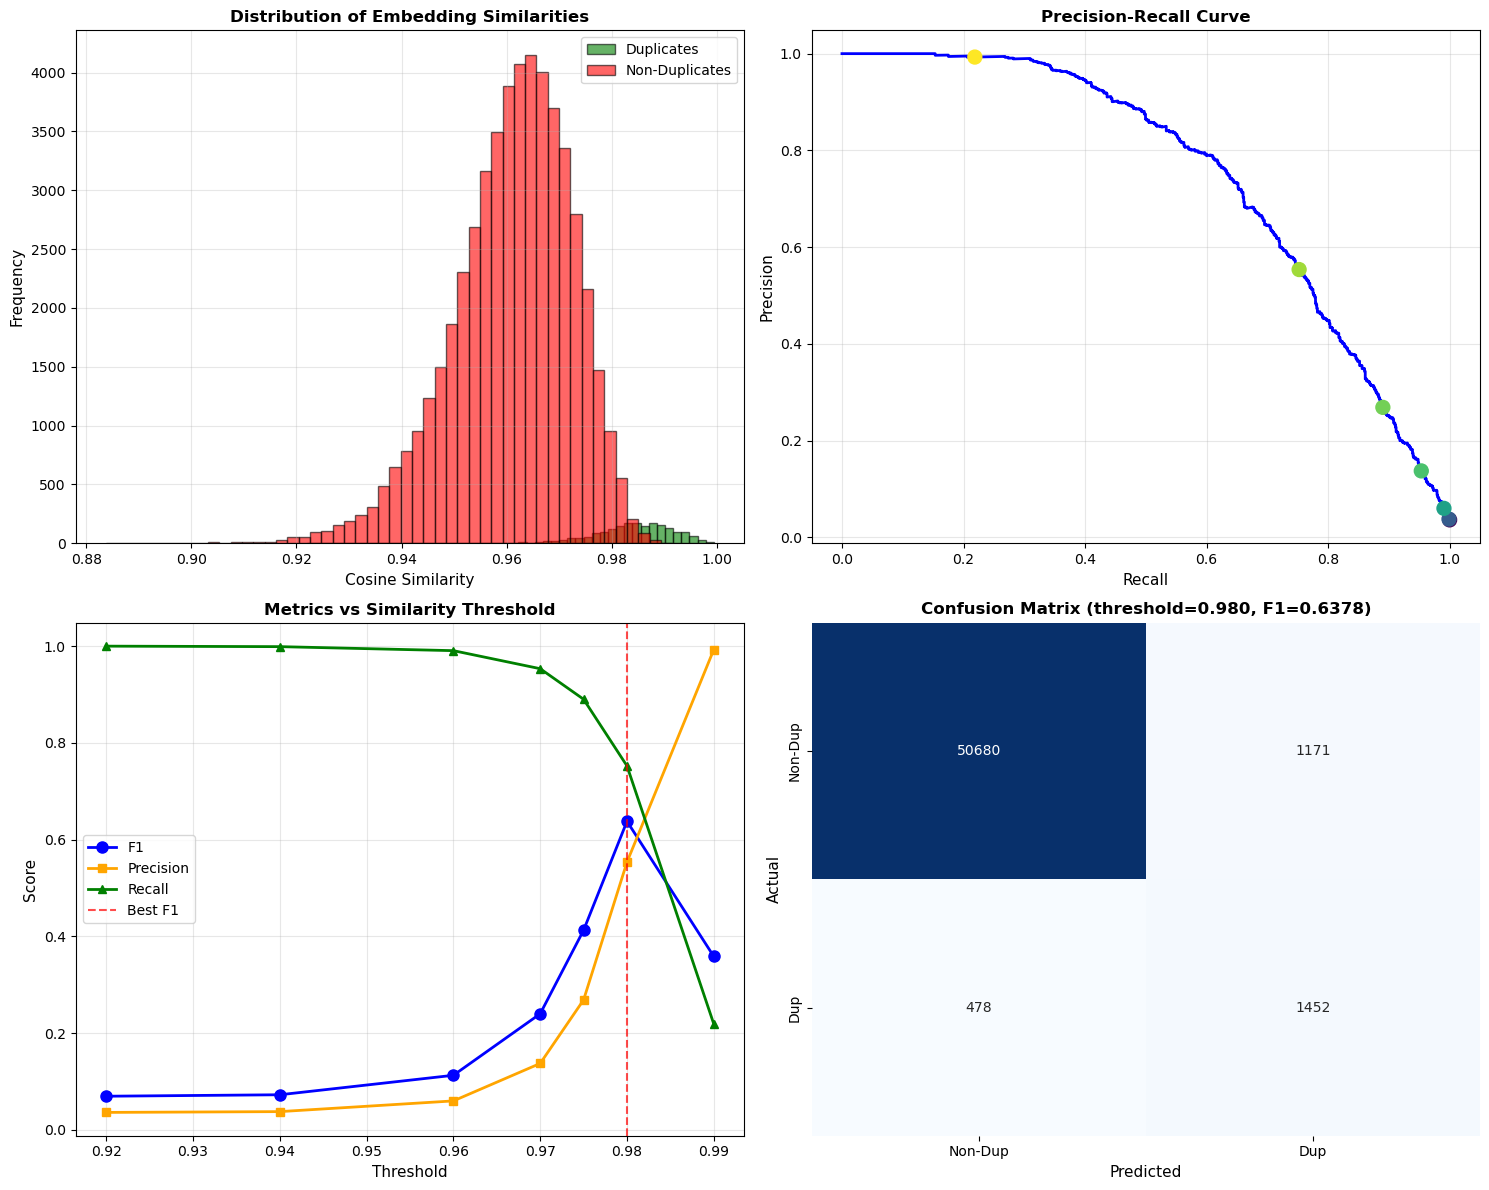


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035965 1.000000 0.069432  0.038062 1930 51734    0   117
     0.940   0.037586 0.998964 0.072446  0.082018 1928 49368    2  2483
     0.960   0.059750 0.990674 0.112703  0.440211 1912 30088   18 21763
     0.970   0.137221 0.953368 0.239911  0.783213 1840 11569   90 40282
     0.975   0.268605 0.890155 0.412683  0.909076 1718  4678  212 47173
     0.980   0.553565 0.752332 0.637821  0.969339 1452  1171  478 50680
     0.990   0.992941 0.218653 0.358386  0.971905  422     3 1508 51848
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.8113 at threshold 0.980


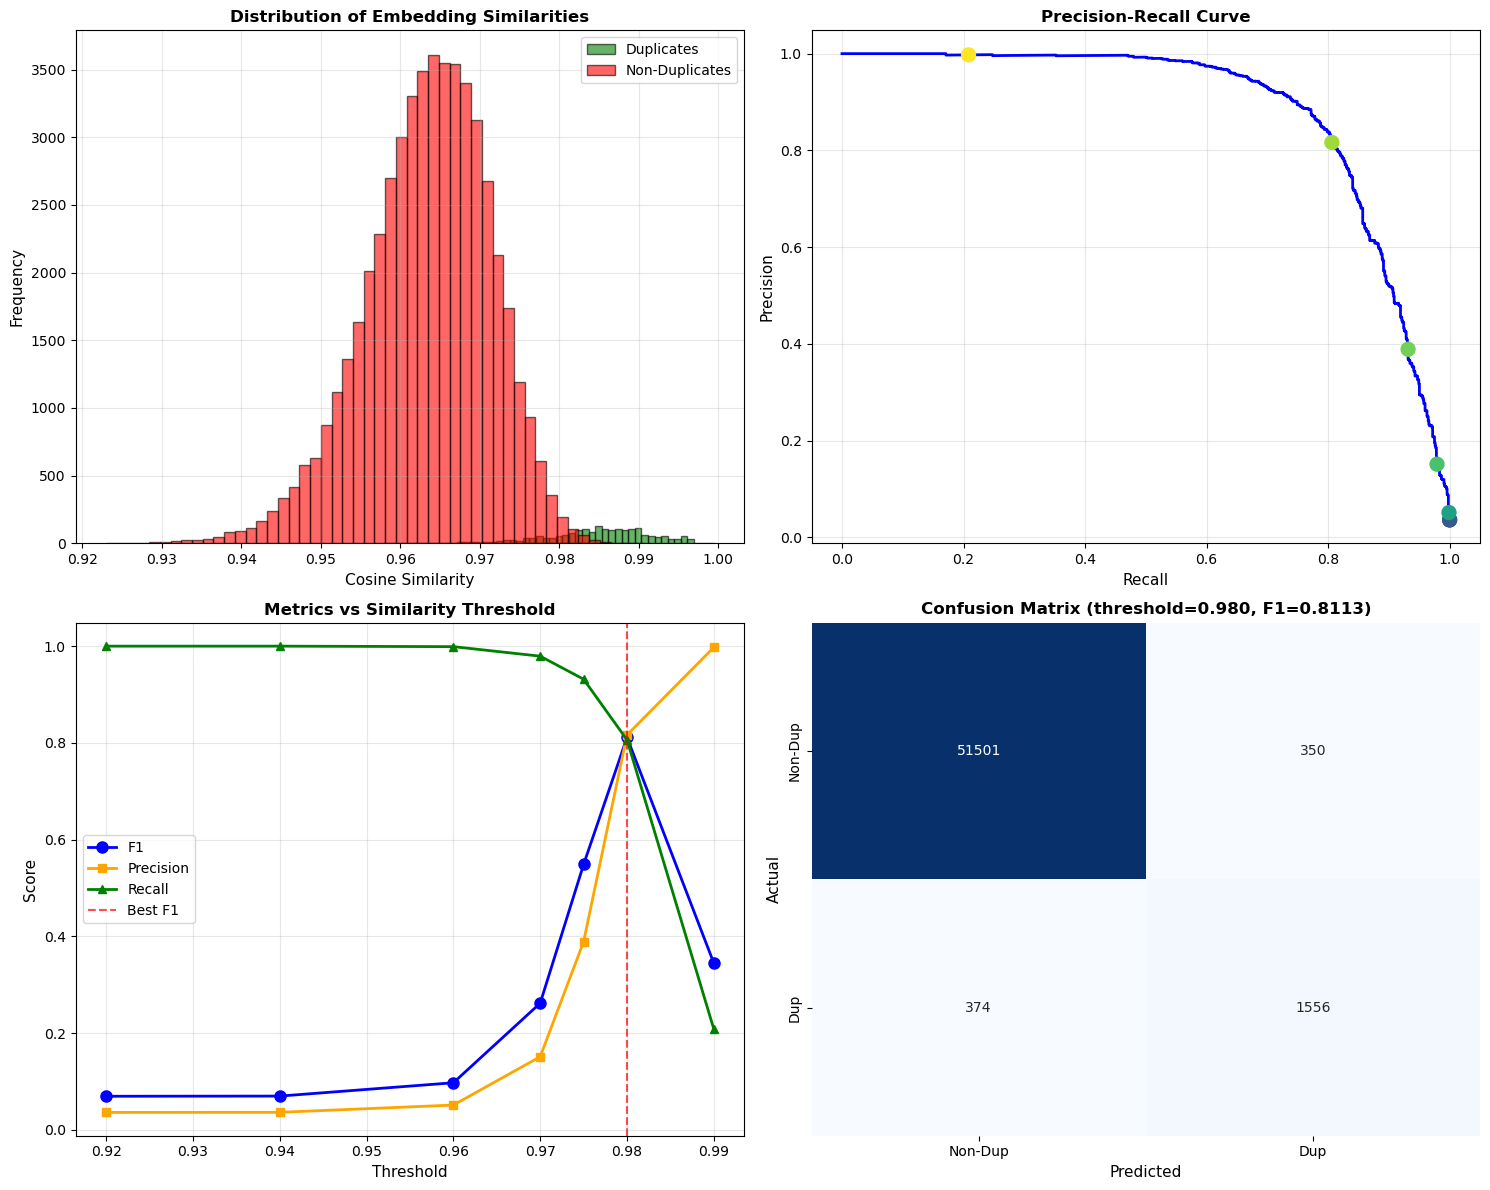


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.036083 1.000000 0.069652  0.041334 1930 51558    0   293
     0.960   0.051090 0.998964 0.097209  0.334133 1928 35809    2 16042
     0.970   0.151043 0.979275 0.261718  0.801733 1890 10623   40 41228
     0.975   0.388757 0.931606 0.548589  0.944981 1798  2827  132 49024
     0.980   0.816369 0.806218 0.811262  0.986538 1556   350  374 51501
     0.990   0.997519 0.208290 0.344621  0.971570  402     1 1528 51850
Model Configuration:
  vocab_size=38, embed_dim=64
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.8763 at threshold 0.980


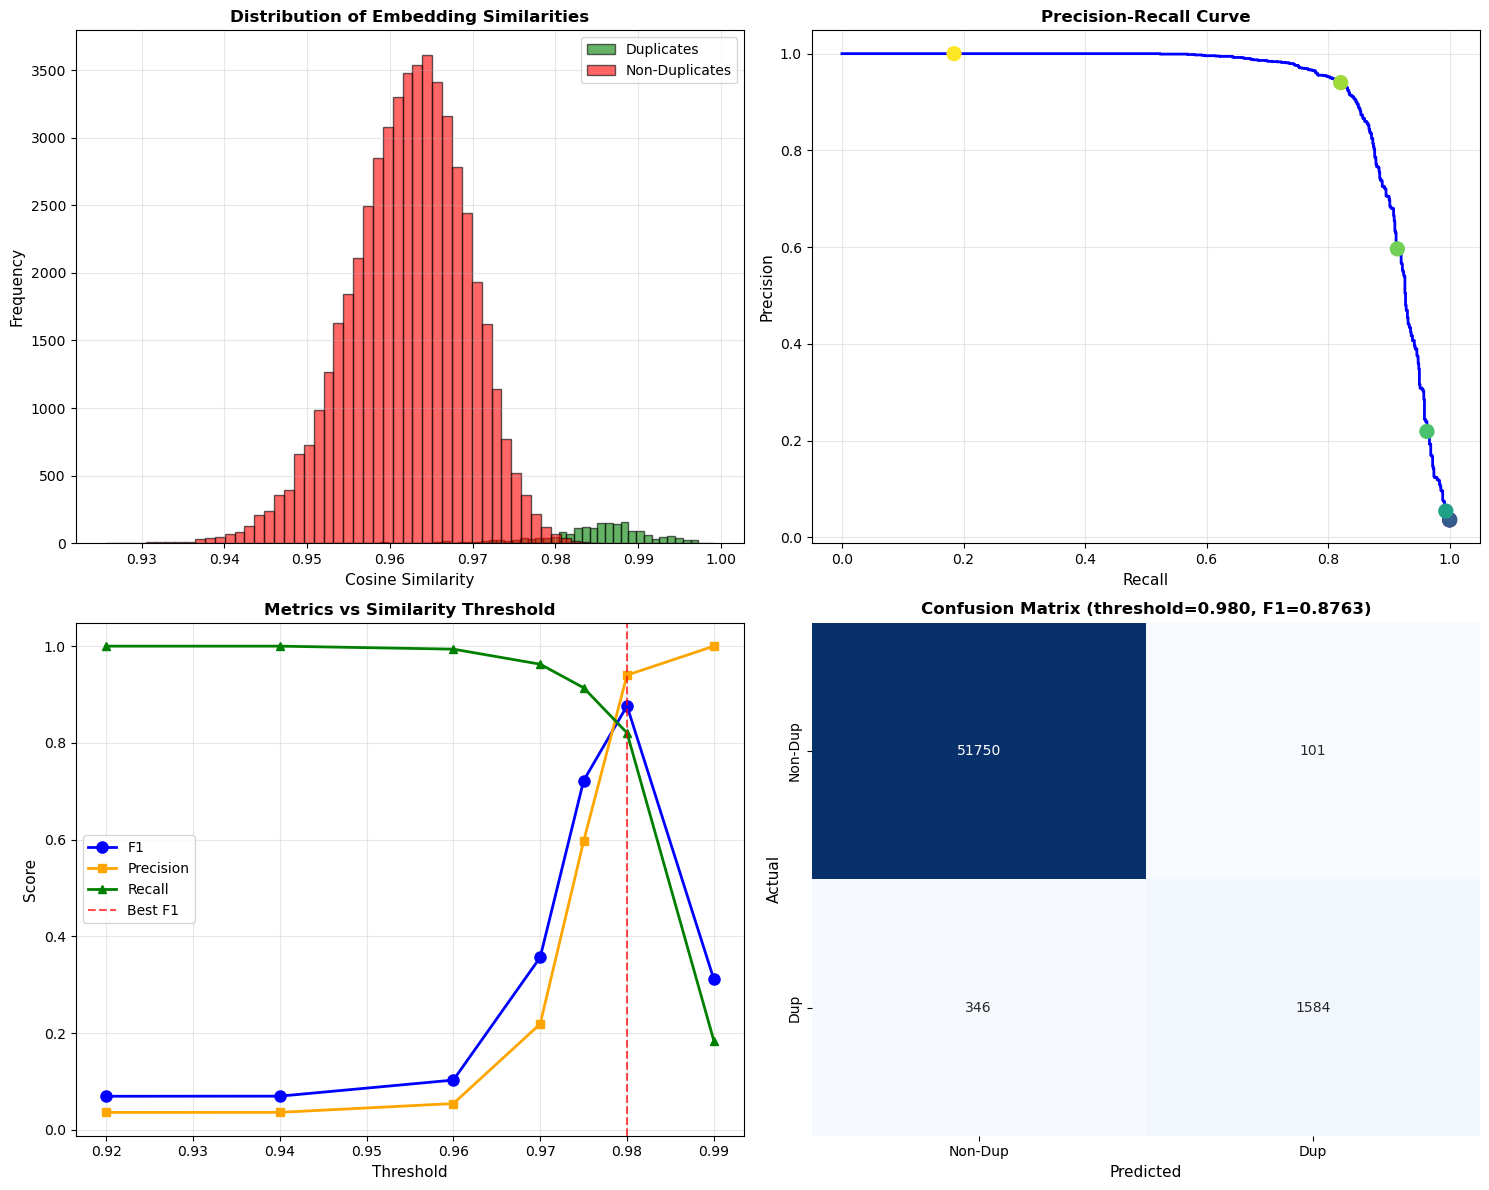


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035886 1.000000 0.069286  0.035886 1930 51851    0     0
     0.940   0.035999 1.000000 0.069497  0.039029 1930 51682    0   169
     0.960   0.054176 0.993782 0.102751  0.377159 1918 33485   12 18366
     0.970   0.218794 0.962694 0.356553  0.875309 1858  6634   72 45217
     0.975   0.596349 0.913990 0.721768  0.974712 1764  1194  166 50657
     0.980   0.940059 0.820725 0.876349  0.991689 1584   101  346 51750
     0.990   1.000000 0.184456 0.311461  0.970733  356     0 1574 51851


In [224]:
embed_dims = [8,16,32,64]
output_dims = [16,32,64,128]

for embed in embed_dims:
    for output in output_dims:
        evaluate_model(ids_data=train_ids_data,
        pairs_data=train_last_name_pairs,
        vocab_size=38, embed_dim=embed, num_filters=128, 
                   kernel_sizes=(3, 4, 5), dropout=0.3, output_dim=output)

Evaluating embed_dim=8, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16

   Best F1: 0.3478 at threshold 0.990


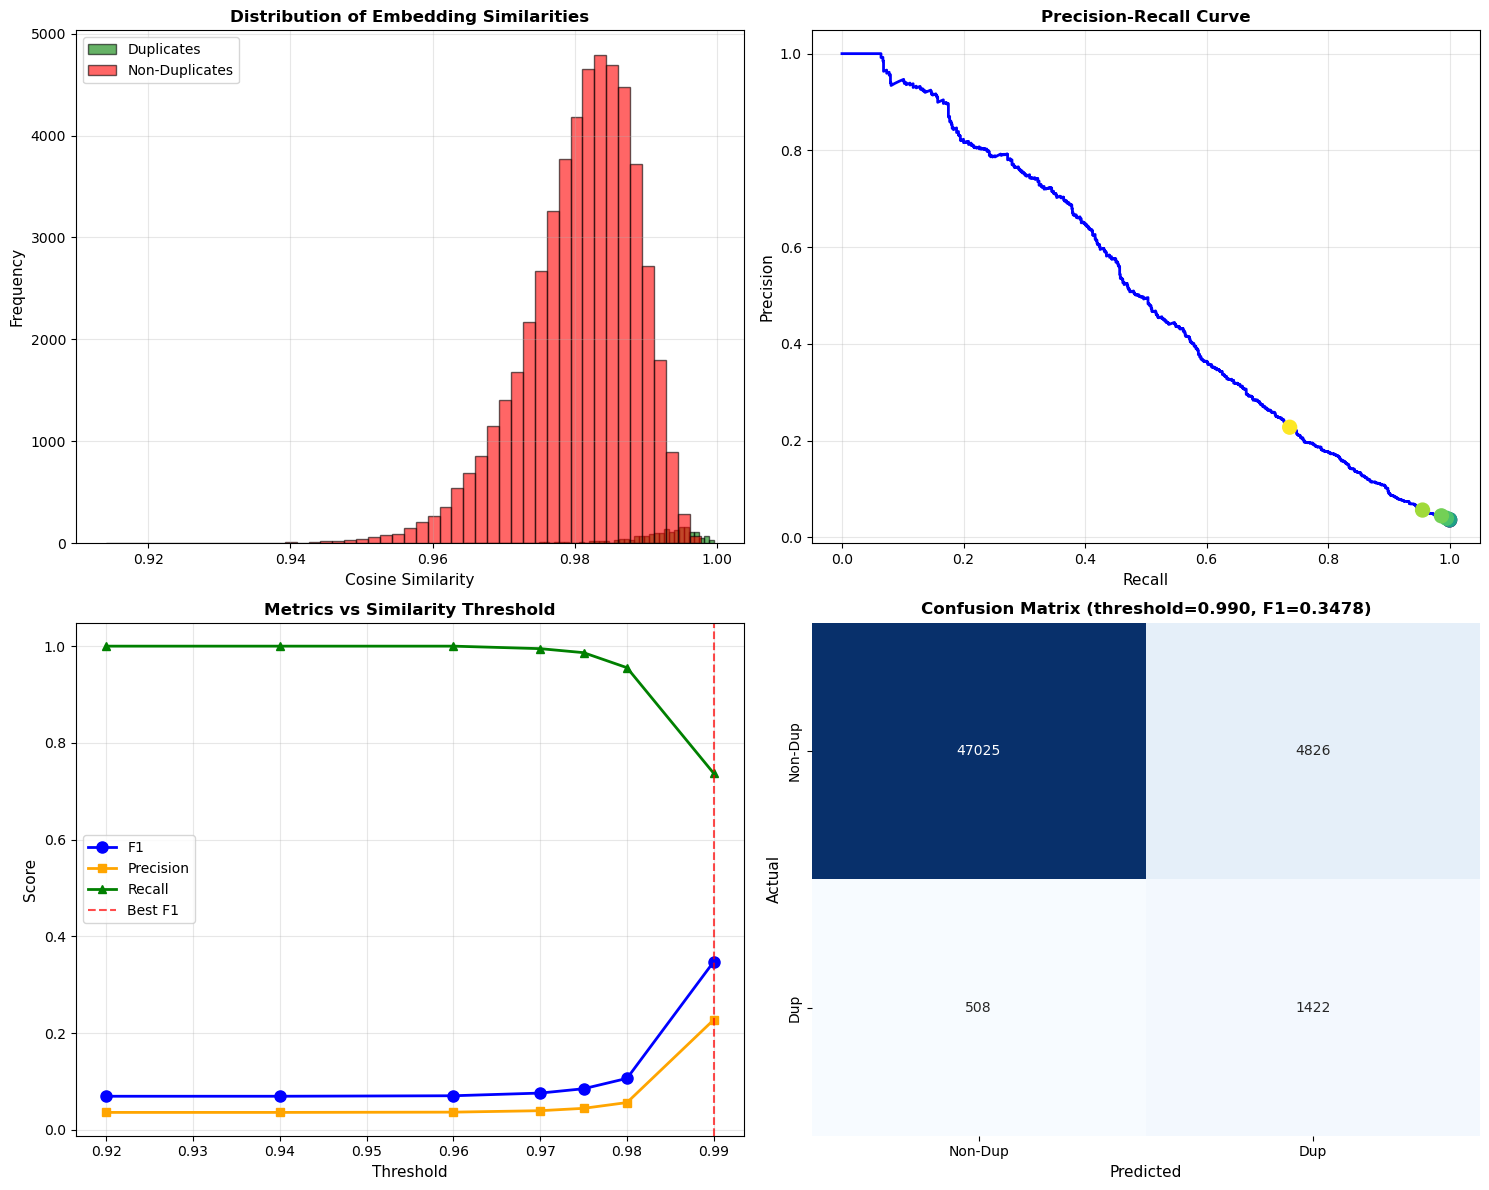


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP  FN    TN
     0.920   0.035887 1.000000 0.069287  0.035905 1930 51850   0     1
     0.940   0.035896 1.000000 0.069304  0.036147 1930 51837   0    14
     0.960   0.036448 1.000000 0.070333  0.051301 1930 51022   0   829
     0.970   0.039427 0.994819 0.075847  0.130027 1920 46778  10  5073
     0.975   0.044319 0.986528 0.084828  0.236106 1904 41057  26 10794
     0.980   0.056264 0.955440 0.106270  0.423291 1844 30930  86 20921
     0.990   0.227593 0.736788 0.347762  0.900820 1422  4826 508 47025
Evaluating embed_dim=8, output_dim=32
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=32

   Best F1: 0.6676 at threshold 0.980


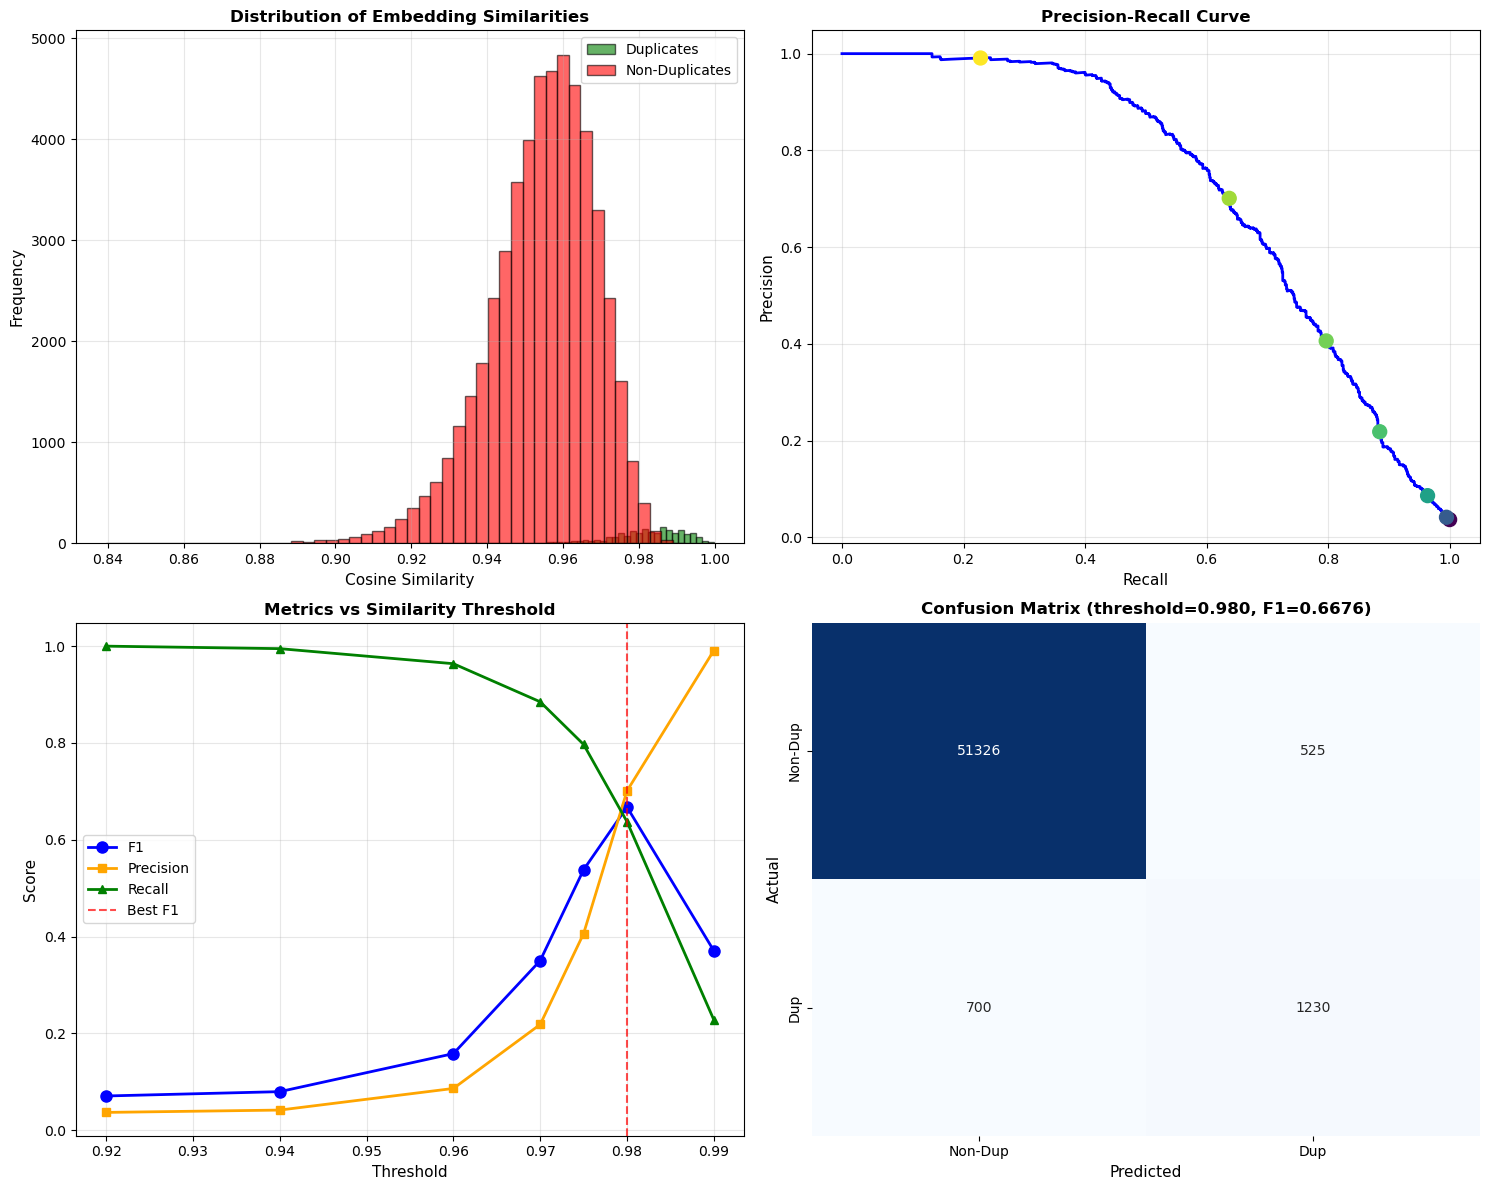


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.036537 1.000000 0.070498  0.053699 1930 50893    0   958
     0.940   0.041369 0.994819 0.079434  0.172533 1920 44492   10  7359
     0.960   0.086043 0.963731 0.157982  0.631338 1860 19757   70 32094
     0.970   0.218275 0.884974 0.350179  0.882133 1708  6117  222 45734
     0.975   0.406019 0.796891 0.537950  0.950875 1538  2250  392 49601
     0.980   0.700855 0.637306 0.667571  0.977222 1230   525  700 51326
     0.990   0.990991 0.227979 0.370682  0.972221  440     4 1490 51847
Evaluating embed_dim=8, output_dim=64
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=64

   Best F1: 0.7076 at threshold 0.980


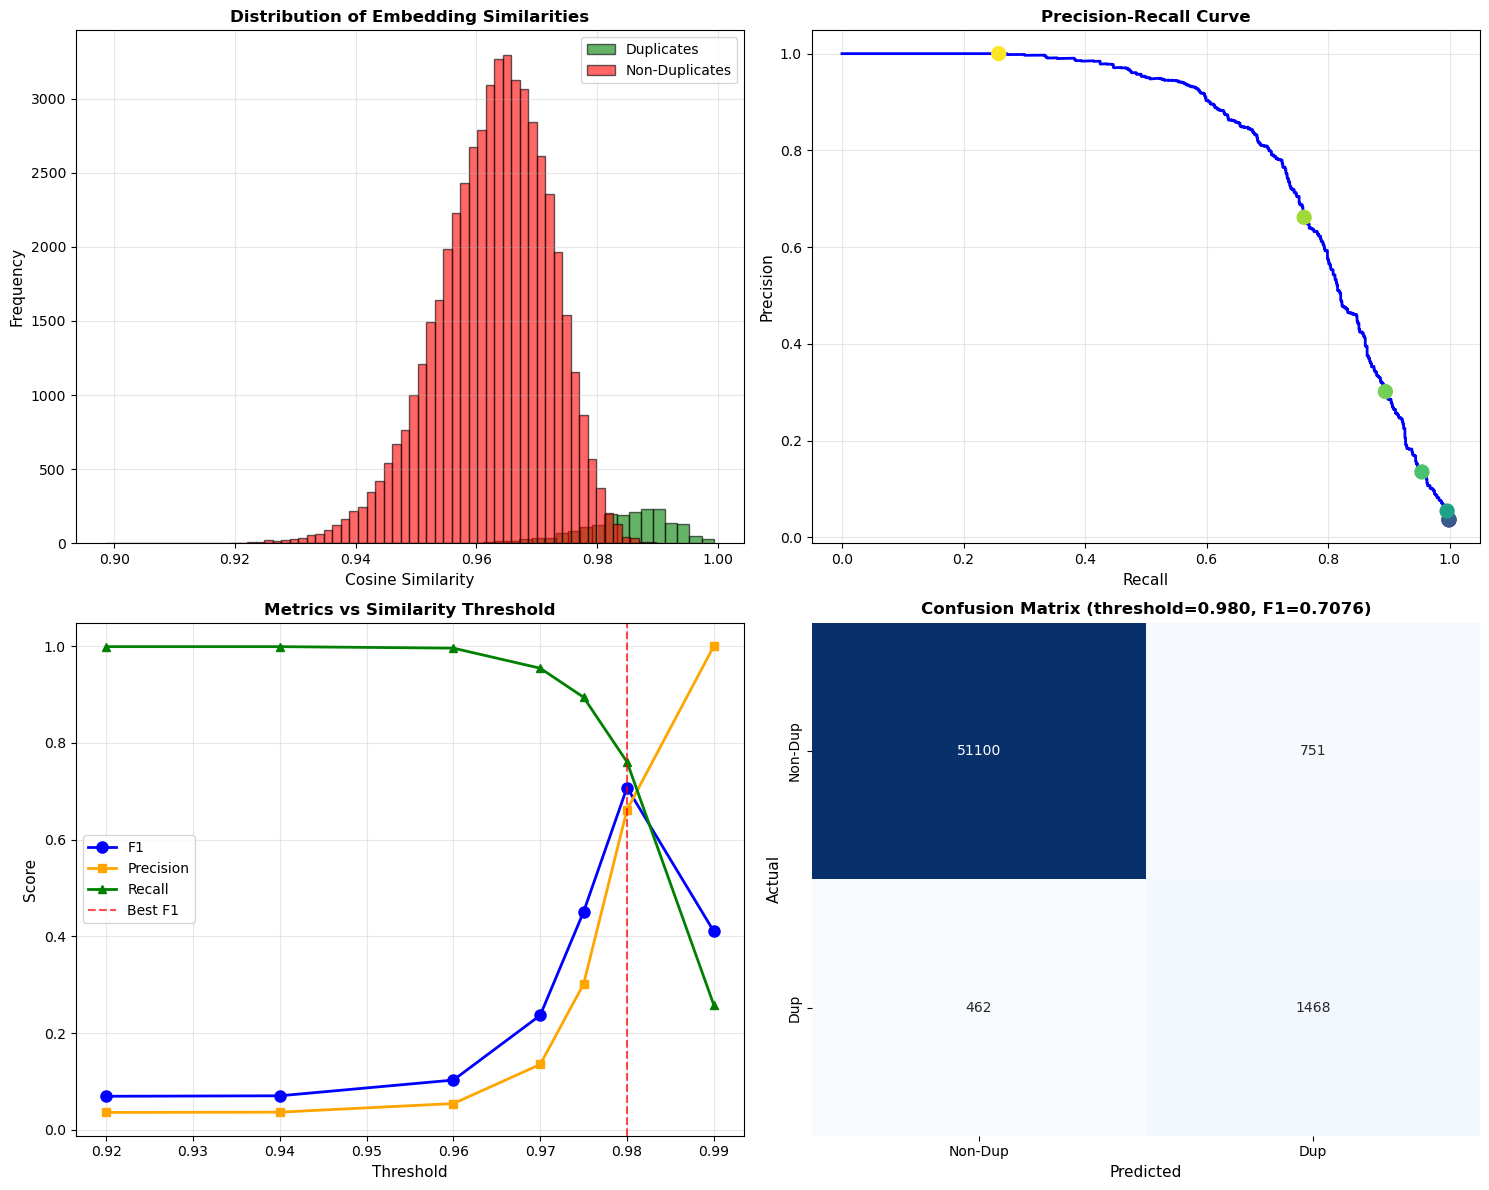


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035852 0.998964 0.069219  0.035886 1928 51849    2     2
     0.940   0.036385 0.998964 0.070212  0.050538 1928 51061    2   790
     0.960   0.054165 0.995855 0.102742  0.375802 1922 33562    8 18289
     0.970   0.135024 0.954404 0.236578  0.778955 1842 11800   88 40051
     0.975   0.301222 0.894301 0.450653  0.921757 1726  4004  204 47847
     0.980   0.661559 0.760622 0.707640  0.977446 1468   751  462 51100
     0.990   1.000000 0.258031 0.410214  0.973373  498     0 1432 51851
Evaluating embed_dim=8, output_dim=128
Model Configuration:
  vocab_size=38, embed_dim=8
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=128

   Best F1: 0.7836 at threshold 0.980


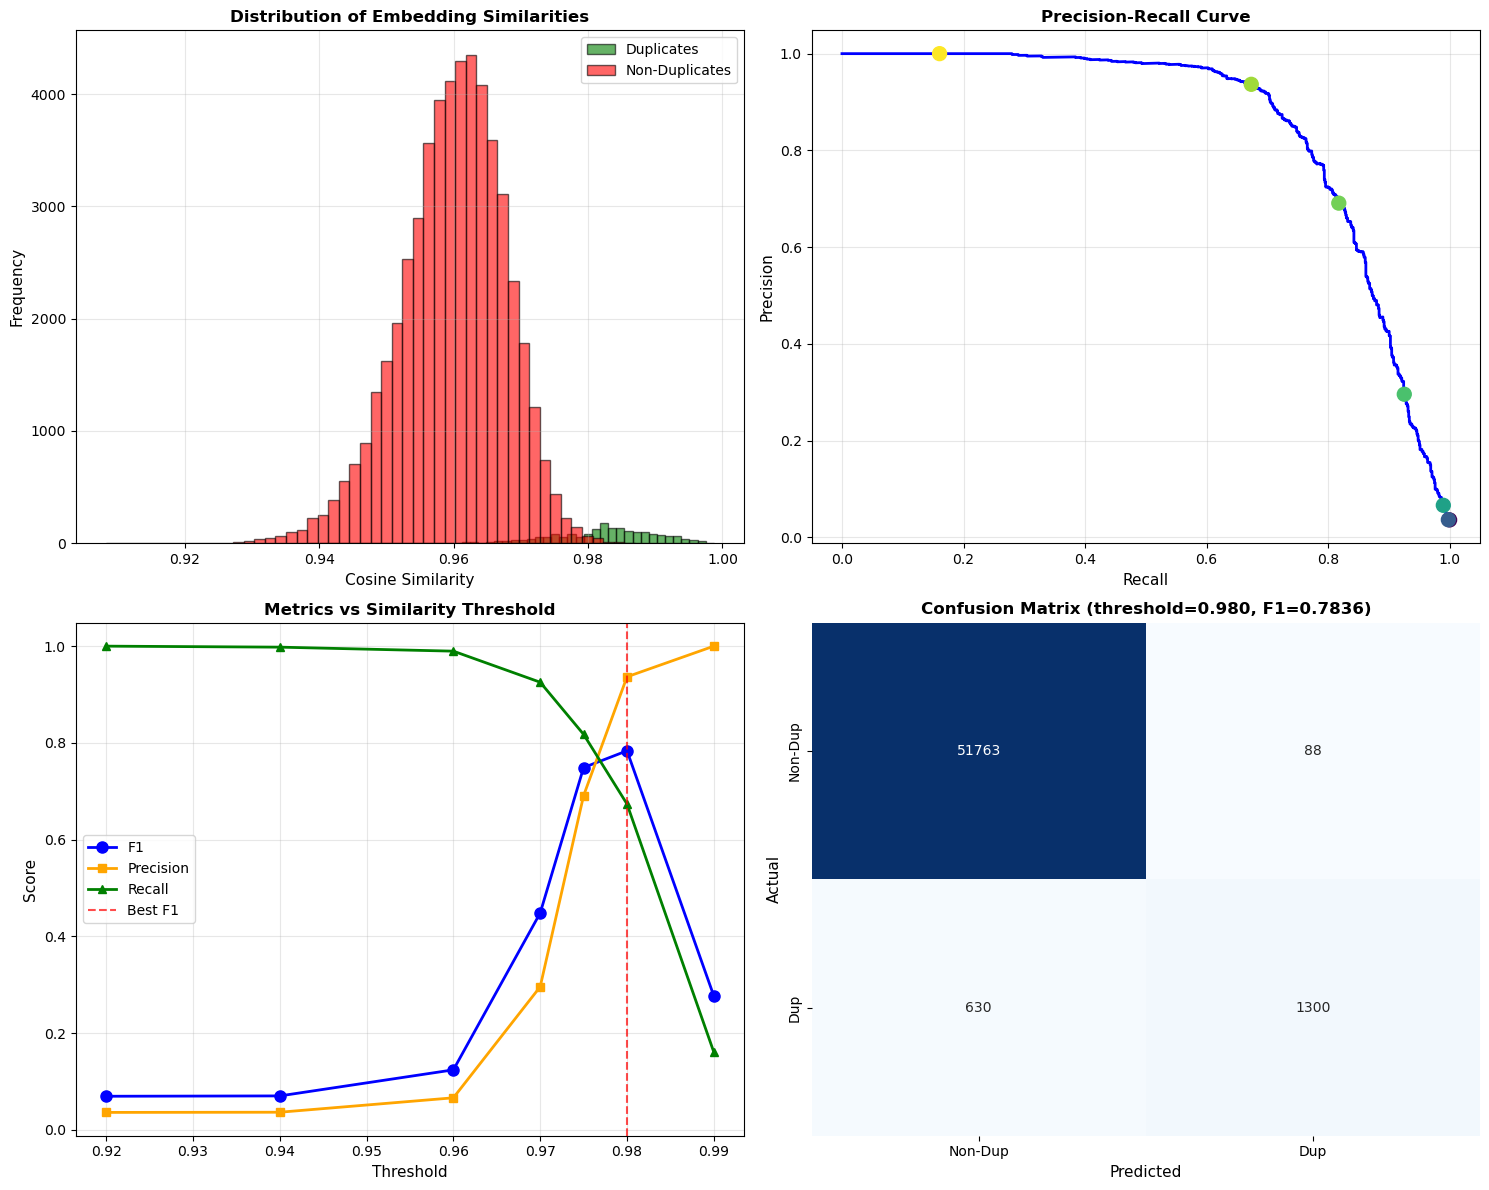


THRESHOLD EVALUATION RESULTS:
 Threshold  Precision   Recall       F1  Accuracy   TP    FP   FN    TN
     0.920   0.035890 1.000000 0.069294  0.035998 1930 51845    0     6
     0.940   0.036268 0.997927 0.069992  0.048307 1926 51179    4   672
     0.960   0.066092 0.989637 0.123909  0.497797 1910 26989   20 24862
     0.970   0.295744 0.925389 0.448237  0.918243 1786  4253  144 47598
     0.975   0.690893 0.817617 0.748932  0.980328 1578   706  352 51145
     0.980   0.936599 0.673575 0.783605  0.986650 1300    88  630 51763
     0.990   1.000000 0.160622 0.276786  0.969878  310     0 1620 51851
Evaluating embed_dim=16, output_dim=16
Model Configuration:
  vocab_size=38, embed_dim=16
  num_filters=128, kernel_sizes=(3, 4, 5)
  dropout=0.3, output_dim=16


In [ ]:
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_recall_curve

import matplotlib.pyplot as plt

# Define the dimensions to test
embed_dims = [8, 16, 32, 64]
output_dims = [16, 32, 64, 128]

# Collect results in a list
results_list = []

for embed in embed_dims:
    for output in output_dims:
        print(f"Evaluating embed_dim={embed}, output_dim={output}")
        result = evaluate_model(
            ids_data=train_ids_data,
            pairs_data=train_last_name_pairs,
            vocab_size=38,
            embed_dim=embed,
            num_filters=128,
            kernel_sizes=(3, 4, 5),
            dropout=0.3,
            output_dim=output
        )
        results_list.append({
            'embed_dim': embed,
            'output_dim': output,
            'best_f1': result['best_f1']
        })

# Create a DataFrame from results
results_df = pd.DataFrame(results_list)

# Pivot to create a grid (embed_dim as rows, output_dim as columns)
f1_grid = results_df.pivot(index='embed_dim', columns='output_dim', values='best_f1')

# Display the grid as a table
print("F1 Scores Grid (embed_dim vs output_dim):")
print(f1_grid)

# Visualize as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(f1_grid, annot=True, fmt=".4f", cmap="viridis", cbar_kws={'label': 'F1 Score'})
plt.title('F1 Scores Heatmap: embed_dim vs output_dim')
plt.xlabel('output_dim')
plt.ylabel('embed_dim')
plt.show()